In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA
import pandas as pd
from plotnine import ggplot, aes, geom_point, theme_minimal, labs, scale_color_gradient, theme, element_text



#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import anndata
from scipy import stats
import warnings
import logging

working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering"
os.chdir(working_dic)

#color key define
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#4C4DB7"])

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()
sc.settings.set_figure_params(dpi=100, color_map='RdBu_r')

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-sn0d8u3f because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Running Scanpy 1.11.0, on 2025-05-18 20:48.


In [7]:
pig_lymphoids_raw_adata = sc.read("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/pig_lymphoids_raw.h5ad")

In [10]:
adata = pig_lymphoids_raw_adata.copy()

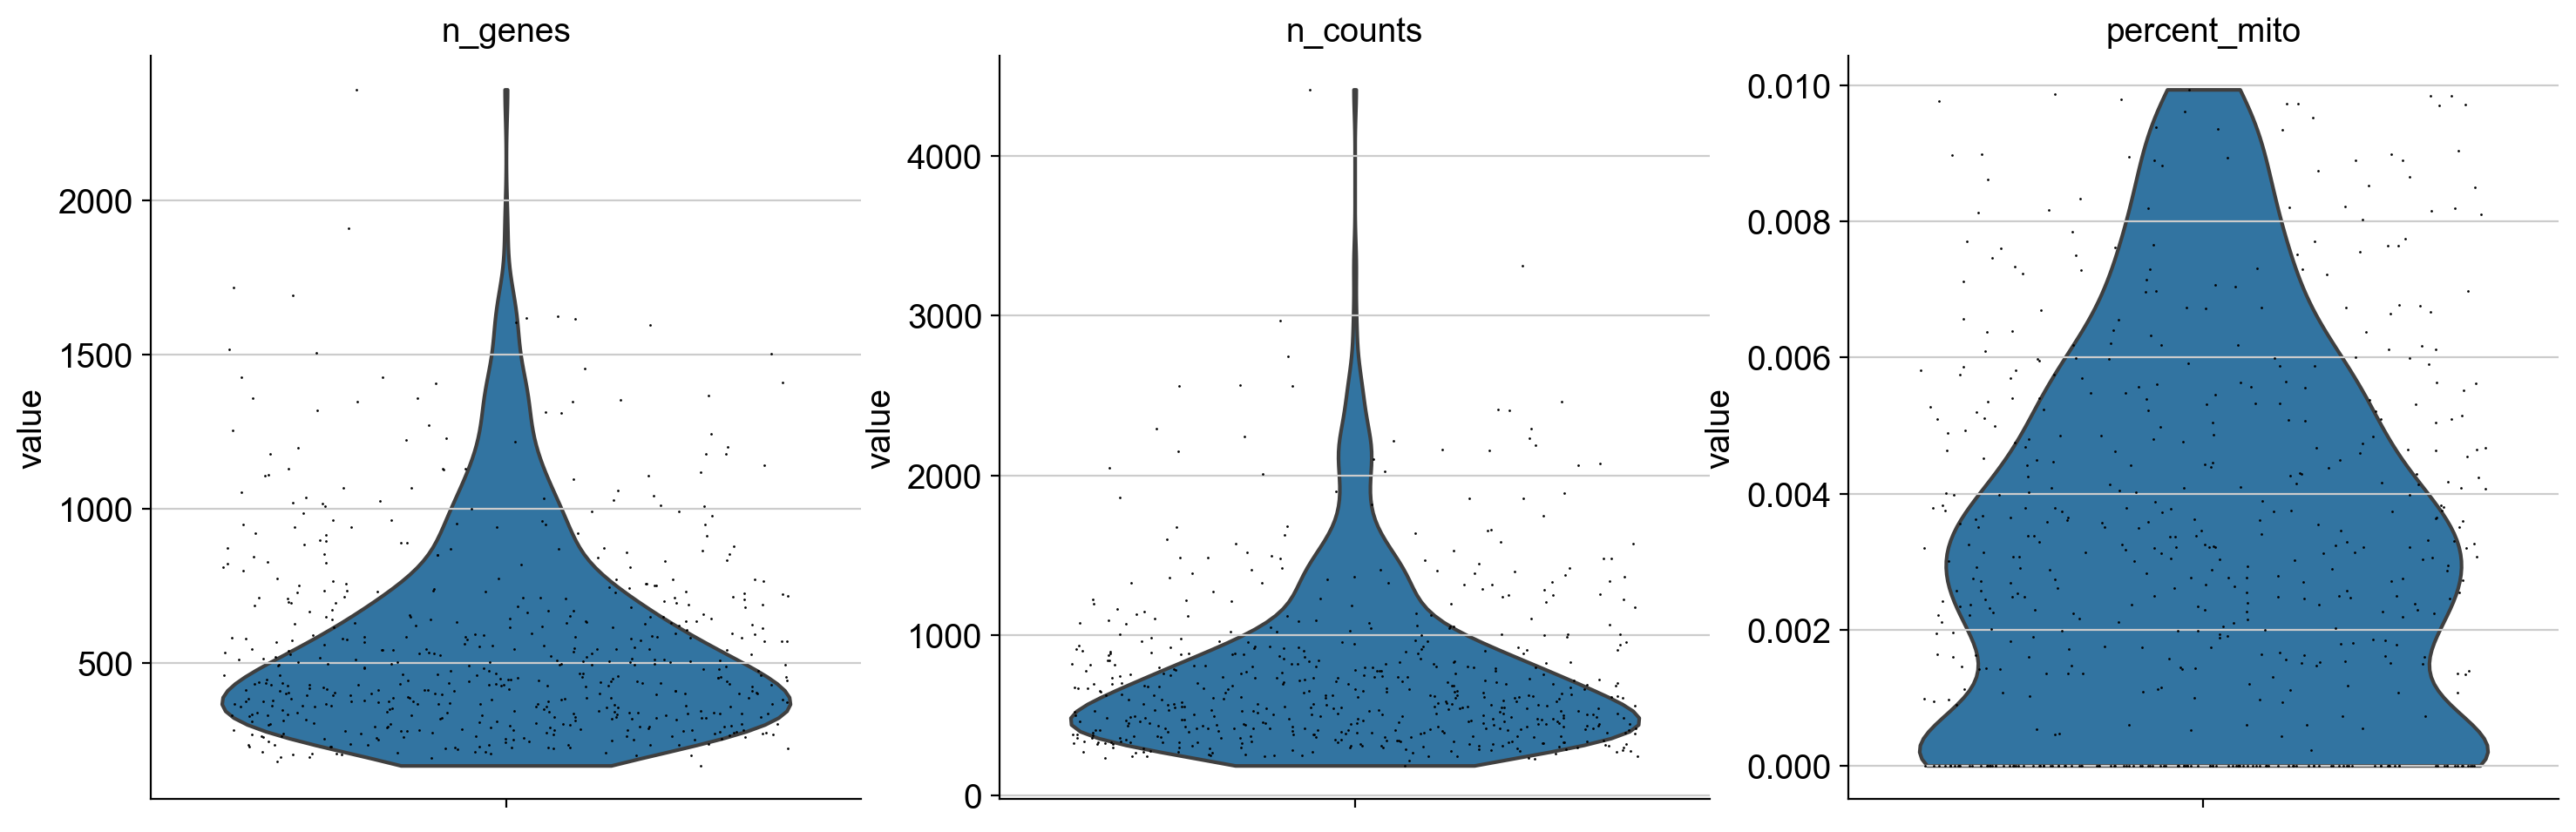

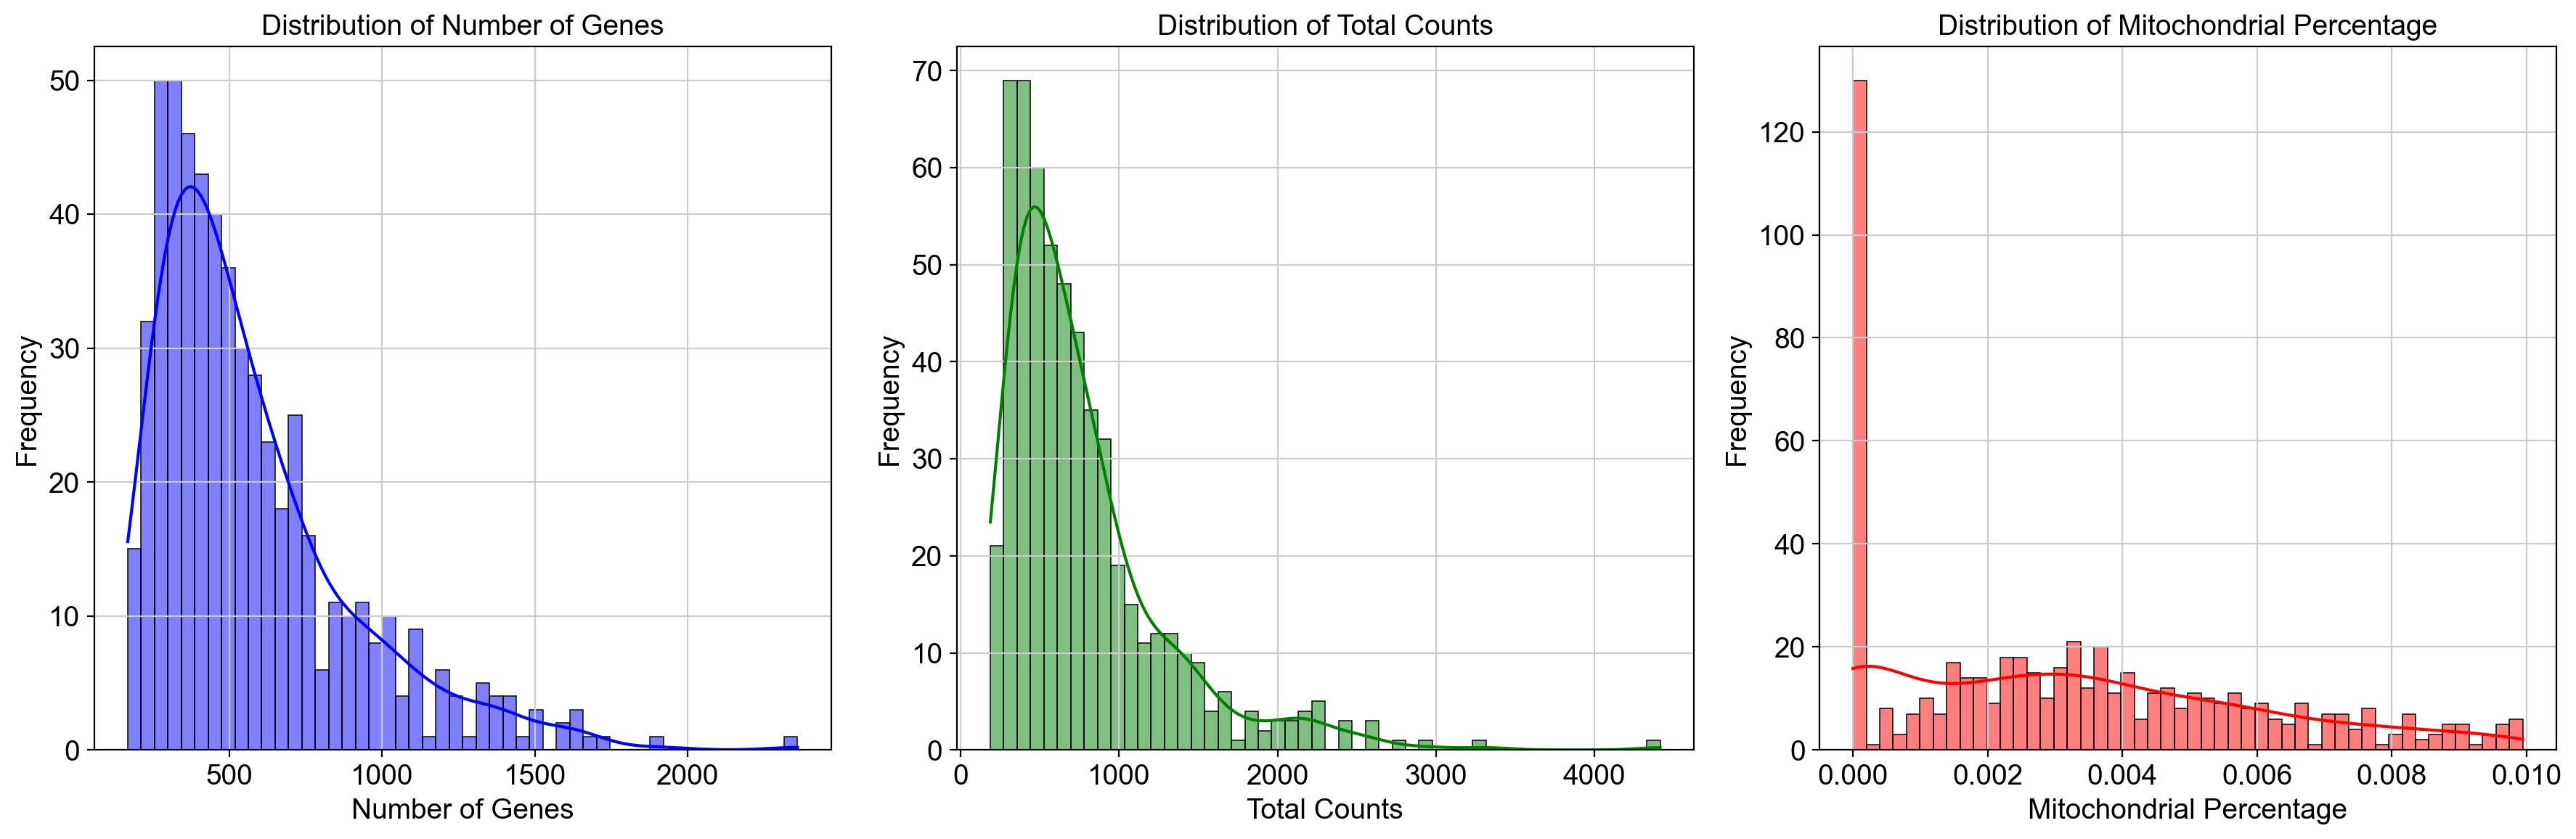

In [11]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

sc.pl.violin(
    adata,
    ["n_genes", "n_counts", "percent_mito"],
    jitter=0.4,
    multi_panel=True)
# 1. Visualize the distribution of key variables (n_genes, n_counts, percent_mito)
# Plot the distribution of n_genes, n_counts, and percent_mito

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(adata.obs['n_genes'], kde=True, ax=axes[0], color='blue', bins=50)
axes[0].set_title('Distribution of Number of Genes')
axes[0].set_xlabel('Number of Genes')
axes[0].set_ylabel('Frequency')

sns.histplot(adata.obs['n_counts'], kde=True, ax=axes[1], color='green', bins=50)
axes[1].set_title('Distribution of Total Counts')
axes[1].set_xlabel('Total Counts')
axes[1].set_ylabel('Frequency')

sns.histplot(adata.obs['percent_mito'], kde=True, ax=axes[2], color='red', bins=50)
axes[2].set_title('Distribution of Mitochondrial Percentage')
axes[2].set_xlabel('Mitochondrial Percentage')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

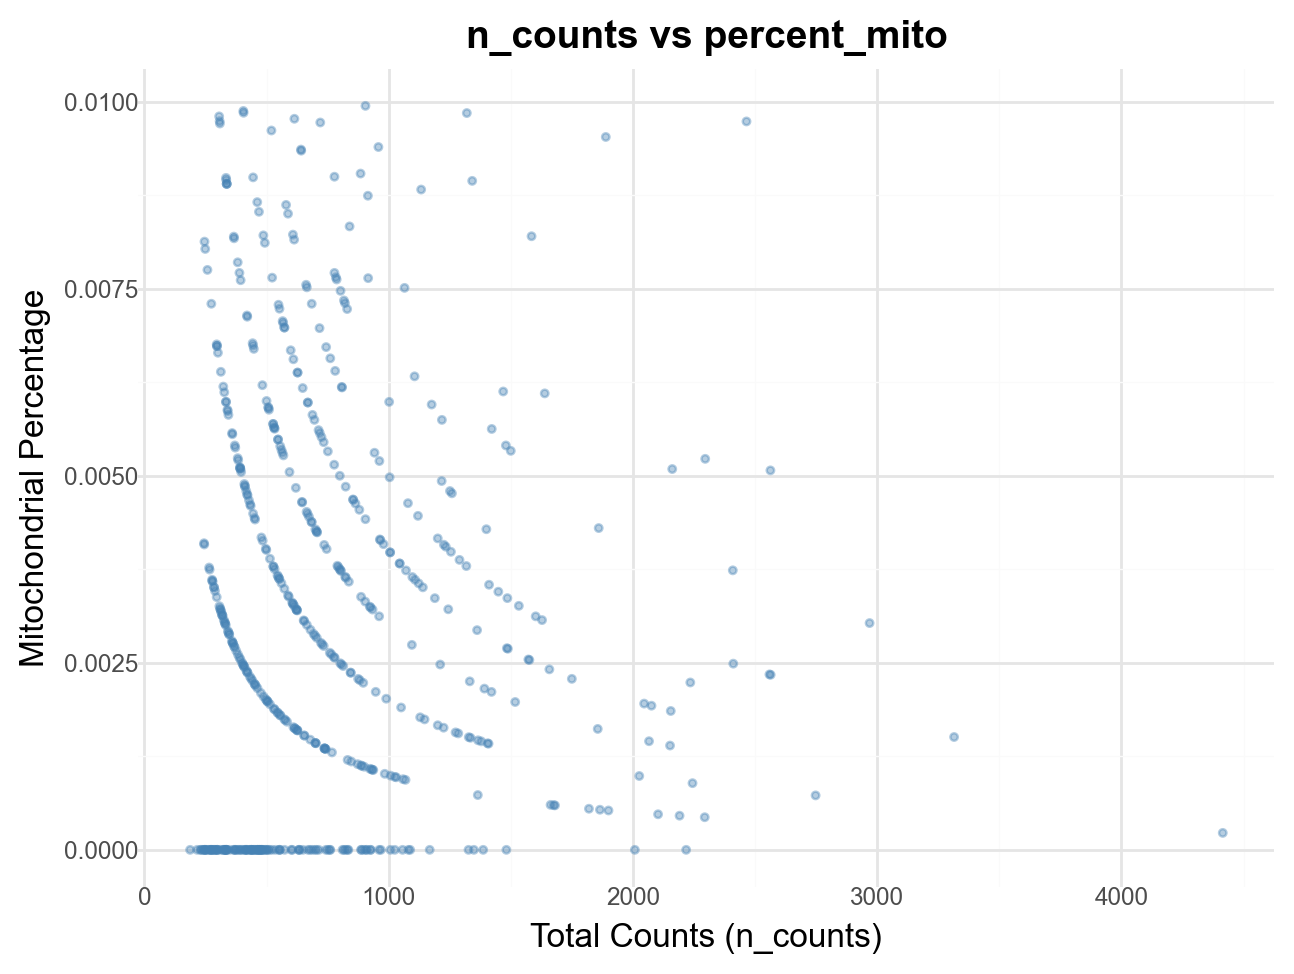

In [12]:
df = adata.obs.copy()
p1 = (
    ggplot(df, aes(x='n_counts', y='percent_mito'))
    + geom_point(alpha=0.4, size=1, color='steelblue')
    + theme_minimal()
    + labs(title='n_counts vs percent_mito',
           x='Total Counts (n_counts)',
           y='Mitochondrial Percentage')
    + theme(axis_title=element_text(size=12), plot_title=element_text(size=14, weight='bold'))
)
p1.draw()

In [16]:
# Step 2: Preprocess - Normalize and Log Transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [17]:
adata_lognorm = adata.write("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/pig_lymphoids_lognorm.h5ad")

In [18]:
adata_lognorm = sc.read("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/pig_lymphoids_lognorm.h5ad")

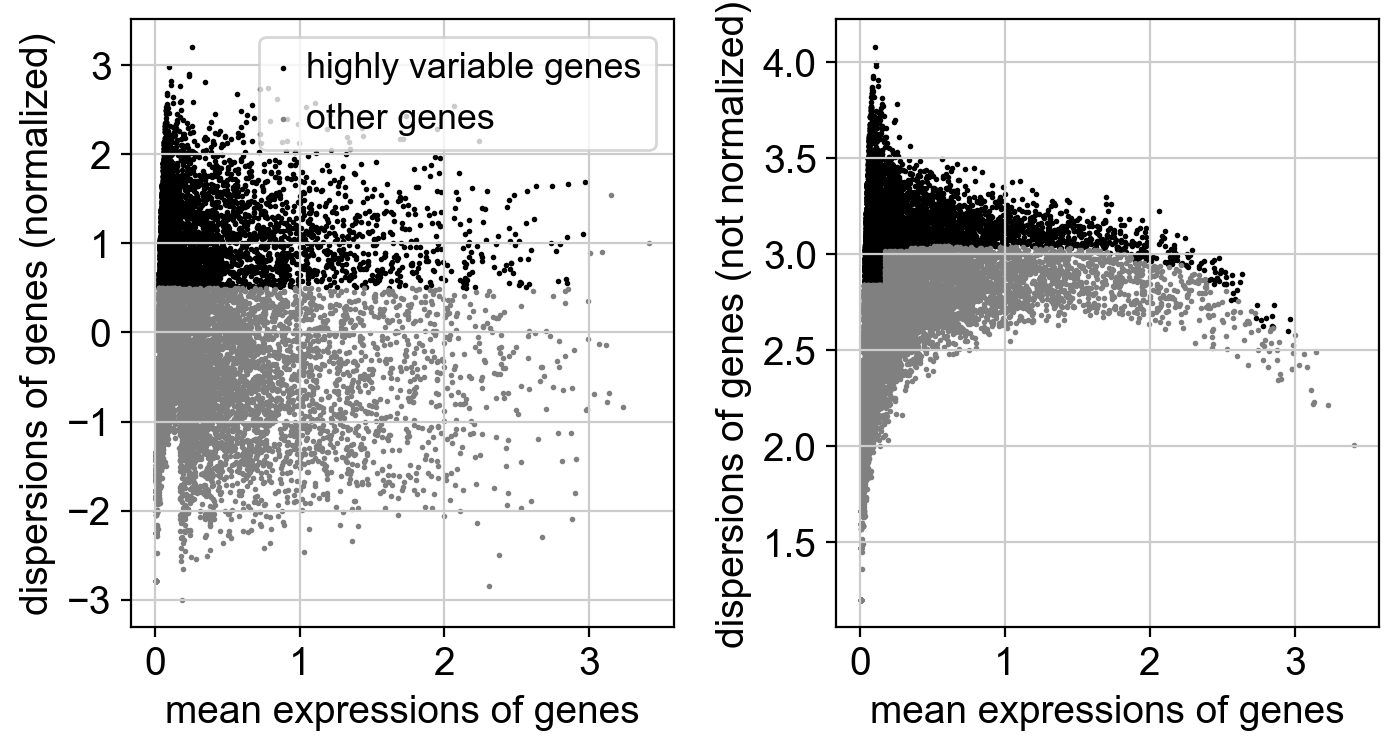

Number of highly variable genes (HVGs): 4120


In [19]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata_lognorm, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Plot highly variable genes

sc.pl.highly_variable_genes(adata_lognorm)

# Count the number of highly variable genes
num_hvgs = adata_lognorm.var['highly_variable'].sum()

# Print the result
print(f"Number of highly variable genes (HVGs): {num_hvgs}")

In [20]:
sc.pp.scale(adata_lognorm, max_value=10)

In [21]:
# Subset the data to HVGs for dimensionality reduction and clustering
adata_hvg = adata_lognorm[:, adata_lognorm.var.highly_variable]

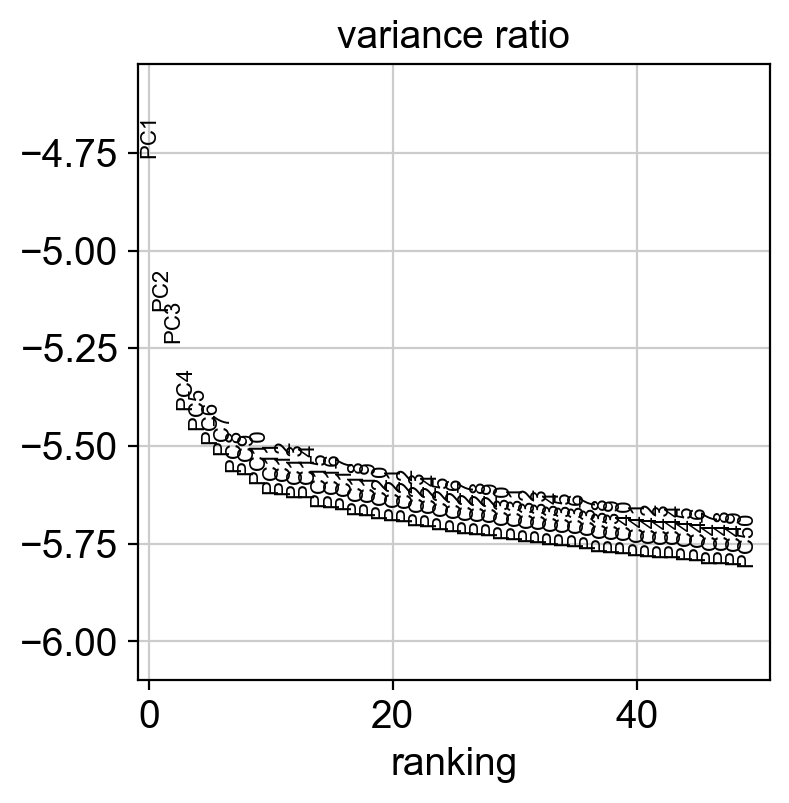

In [22]:
# Perform PCA
sc.tl.pca(adata_hvg, svd_solver='arpack')

# Plot the explained variance to decide how many PCs to use
sc.pl.pca_variance_ratio(adata_hvg, log=True, n_pcs=50)
plt.show()

2025-05-06 16:45:49,474 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-05-06 16:45:49,918 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-05-06 16:45:49,921 - harmonypy - INFO - Iteration 1 of 10
2025-05-06 16:45:49,987 - harmonypy - INFO - Iteration 2 of 10
2025-05-06 16:45:50,048 - harmonypy - INFO - Iteration 3 of 10
2025-05-06 16:45:50,107 - harmonypy - INFO - Iteration 4 of 10
2025-05-06 16:45:50,165 - harmonypy - INFO - Iteration 5 of 10
2025-05-06 16:45:50,223 - harmonypy - INFO - Iteration 6 of 10
2025-05-06 16:45:50,281 - harmonypy - INFO - Iteration 7 of 10
2025-05-06 16:45:50,339 - harmonypy - INFO - Iteration 8 of 10
2025-05-06 16:45:50,397 - harmonypy - INFO - Iteration 9 of 10
2025-05-06 16:45:50,455 - harmonypy - INFO - Iteration 10 of 10
2025-05-06 16:45:50,513 - harmonypy - INFO - Stopped before convergence


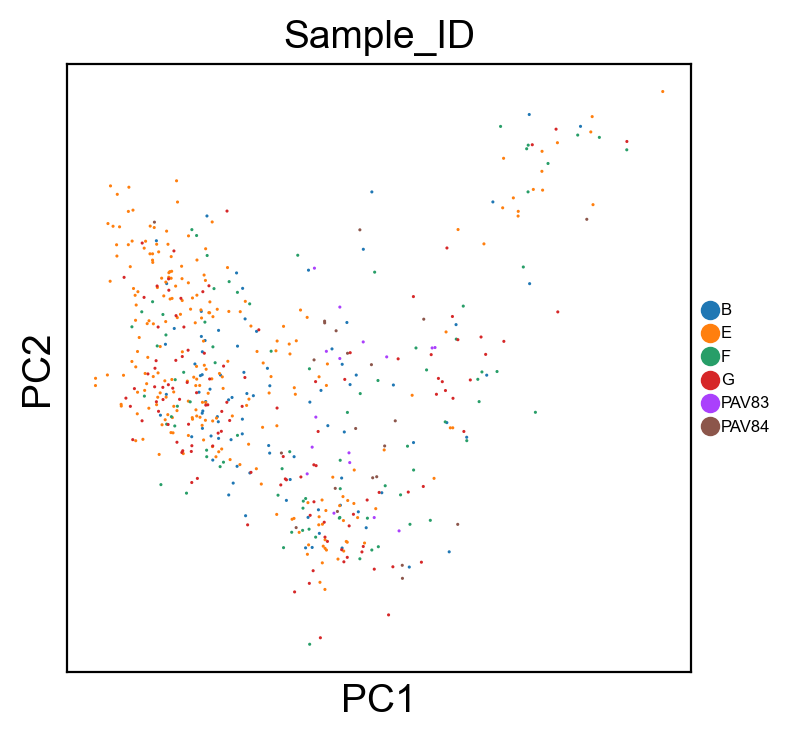

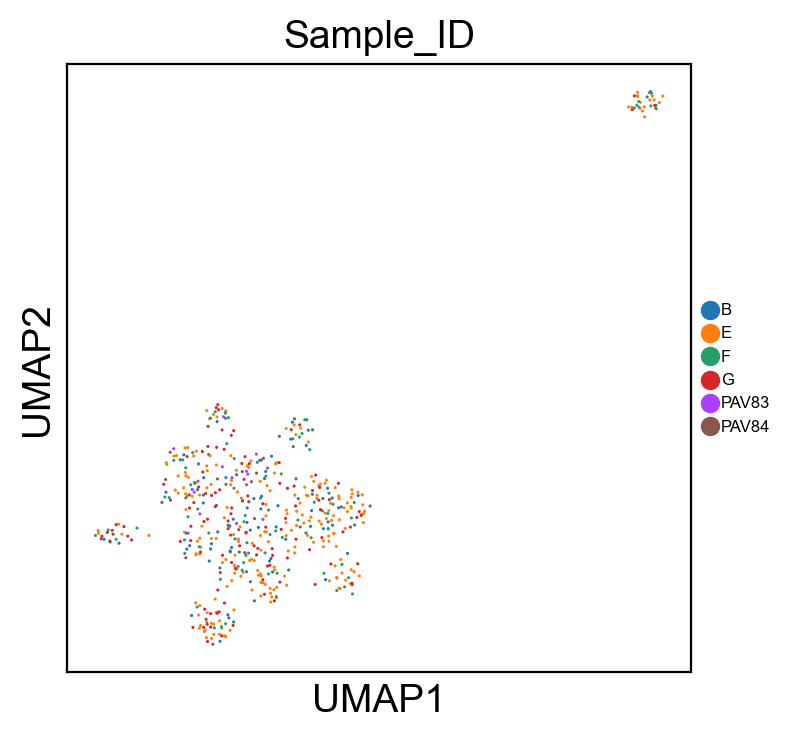

In [23]:
#run harmony
sc.external.pp.harmony_integrate(adata_hvg, "Sample_ID", random_state=15, epsilon_cluster=-np.inf, epsilon_harmony=-np.inf)

sc.pp.neighbors(adata_hvg, n_neighbors=20, n_pcs=30, use_rep="X_pca_harmony")
sc.tl.umap(adata_hvg)
sc.pl.pca_scatter(adata_hvg, color=["Sample_ID"], size=5, legend_fontsize=6)
sc.pl.umap(adata_hvg, color=["Sample_ID"], size=5, legend_fontsize=6)

In [29]:
hm_adata = adata_hvg.write ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/harmonized_hm_lymphoid_adata.h5ad')

In [190]:
hm_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/harmonized_hm_lymphoid_adata.h5ad')

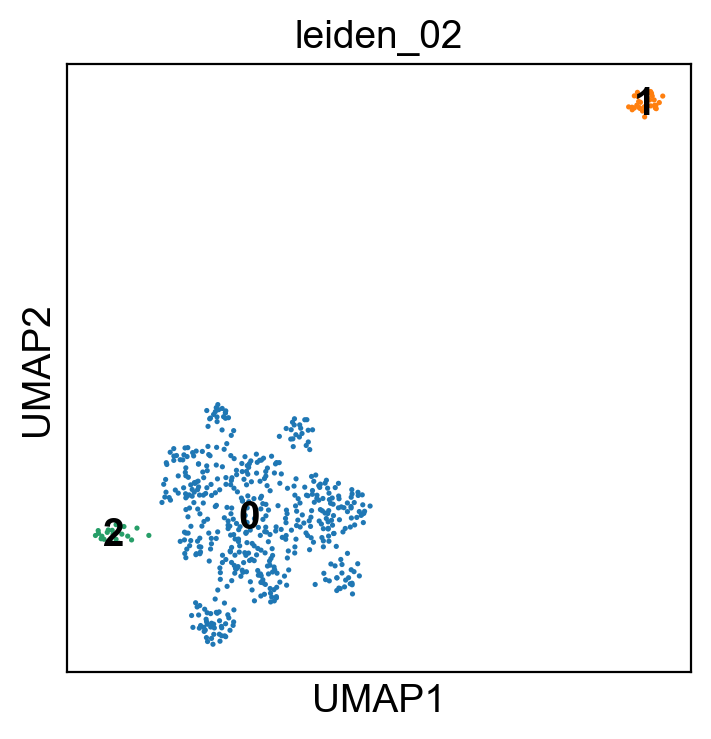

In [198]:
# Run Leiden clustering with the new neighbors graph
sc.tl.leiden(hm_adata, resolution=0.2, key_added="leiden_02", flavor="igraph", directed=False, random_state=15, n_iterations = -1)

# Plot UMAP
sc.pl.umap(
    hm_adata, color=["leiden_02"], legend_loc="on data", size=14
)  

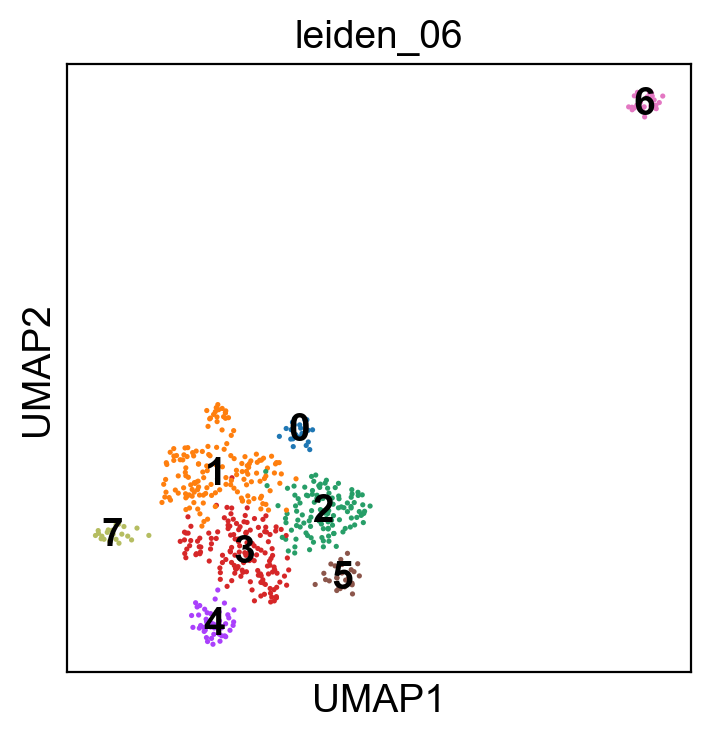

In [4]:
# Run Leiden clustering with the new neighbors graph
sc.tl.leiden(hm_adata, resolution=0.6, key_added="leiden_06", flavor="igraph", directed=False, random_state=15, n_iterations = -1)

# Plot UMAP
sc.pl.umap(
    hm_adata, color=["leiden_06"], legend_loc="on data", size=14
)  

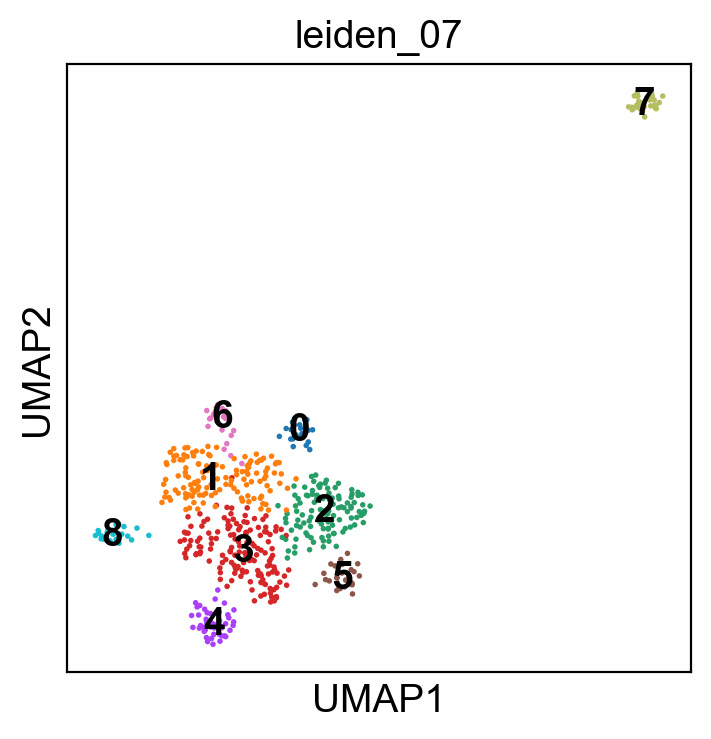

In [5]:
# Run Leiden clustering with the new neighbors graph
sc.tl.leiden(hm_adata, resolution=0.7, key_added="leiden_07", flavor="igraph", directed=False, random_state=15, n_iterations = -1)

# Plot UMAP
sc.pl.umap(
    hm_adata, color=["leiden_07"], legend_loc="on data", size=16
)

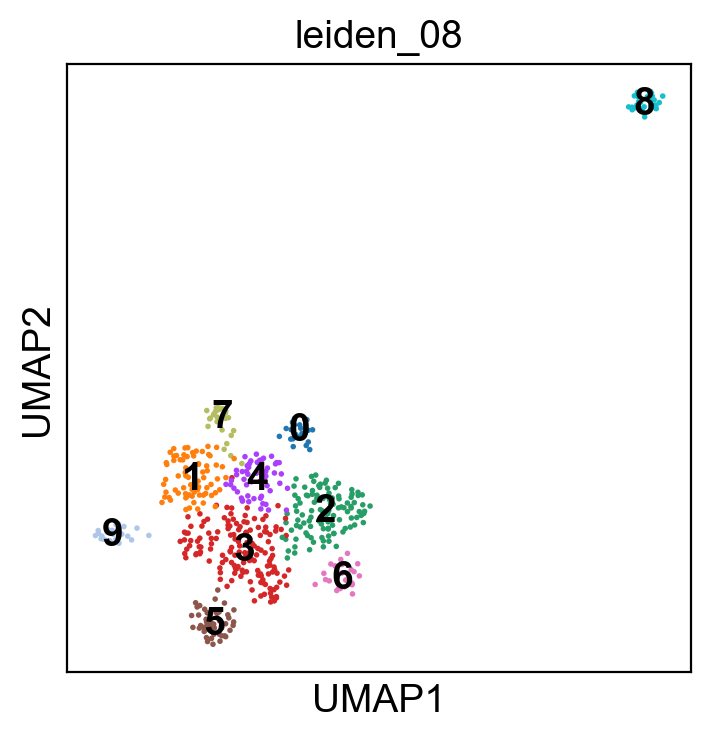

In [6]:
# Run Leiden clustering with the new neighbors graph
sc.tl.leiden(hm_adata, resolution=0.8, key_added="leiden_08", flavor="igraph", directed=False, random_state=15, n_iterations = -1)

# Plot UMAP
sc.pl.umap(
    hm_adata, color=["leiden_08"], legend_loc="on data", size=16
)

In [8]:
lognorm_pig_lymph = sc.read ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/pig_lymphoids_lognorm.h5ad")

In [9]:
# 1️⃣ Transfer 'highly_variable' from clustered_adata.var to log_normalized_adata.var
lognorm_pig_lymph.var["highly_variable"] = False  # Initialize all as False

# Ensure only common genes are updated correctly
common_genes = hm_adata.var.index.intersection(lognorm_pig_lymph.var.index)
lognorm_pig_lymph.var.loc[common_genes, "highly_variable"] = hm_adata.var.loc[common_genes, "highly_variable"]

lognorm_pig_lymph.obs['leiden_08'] = hm_adata.obs['leiden_08']

lognorm_pig_lymph.uns["leiden_08_colors"] = hm_adata.uns["leiden_08_colors"]

lognorm_pig_lymph.obsm["X_pca_harmony"] = hm_adata.obsm["X_pca_harmony"]

lognorm_pig_lymph.obsm["X_umap"] = hm_adata.obsm["X_umap"]

lognorm_pig_lymph.obsp["connectivities"] = hm_adata.obsp["connectivities"]

lognorm_pig_lymph.obsp["distances"] = hm_adata.obsp["distances"]

In [10]:
label_transferred_lognorm_pig_lymph = lognorm_pig_lymph.write ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/label_transferred_lognorm_pig_lymphoids_DEA_08.h5ad")

In [6]:
label_transferred_lognorm_pig_lymph = sc.read ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/label_transferred_lognorm_pig_lymphoids_DEA_08.h5ad")

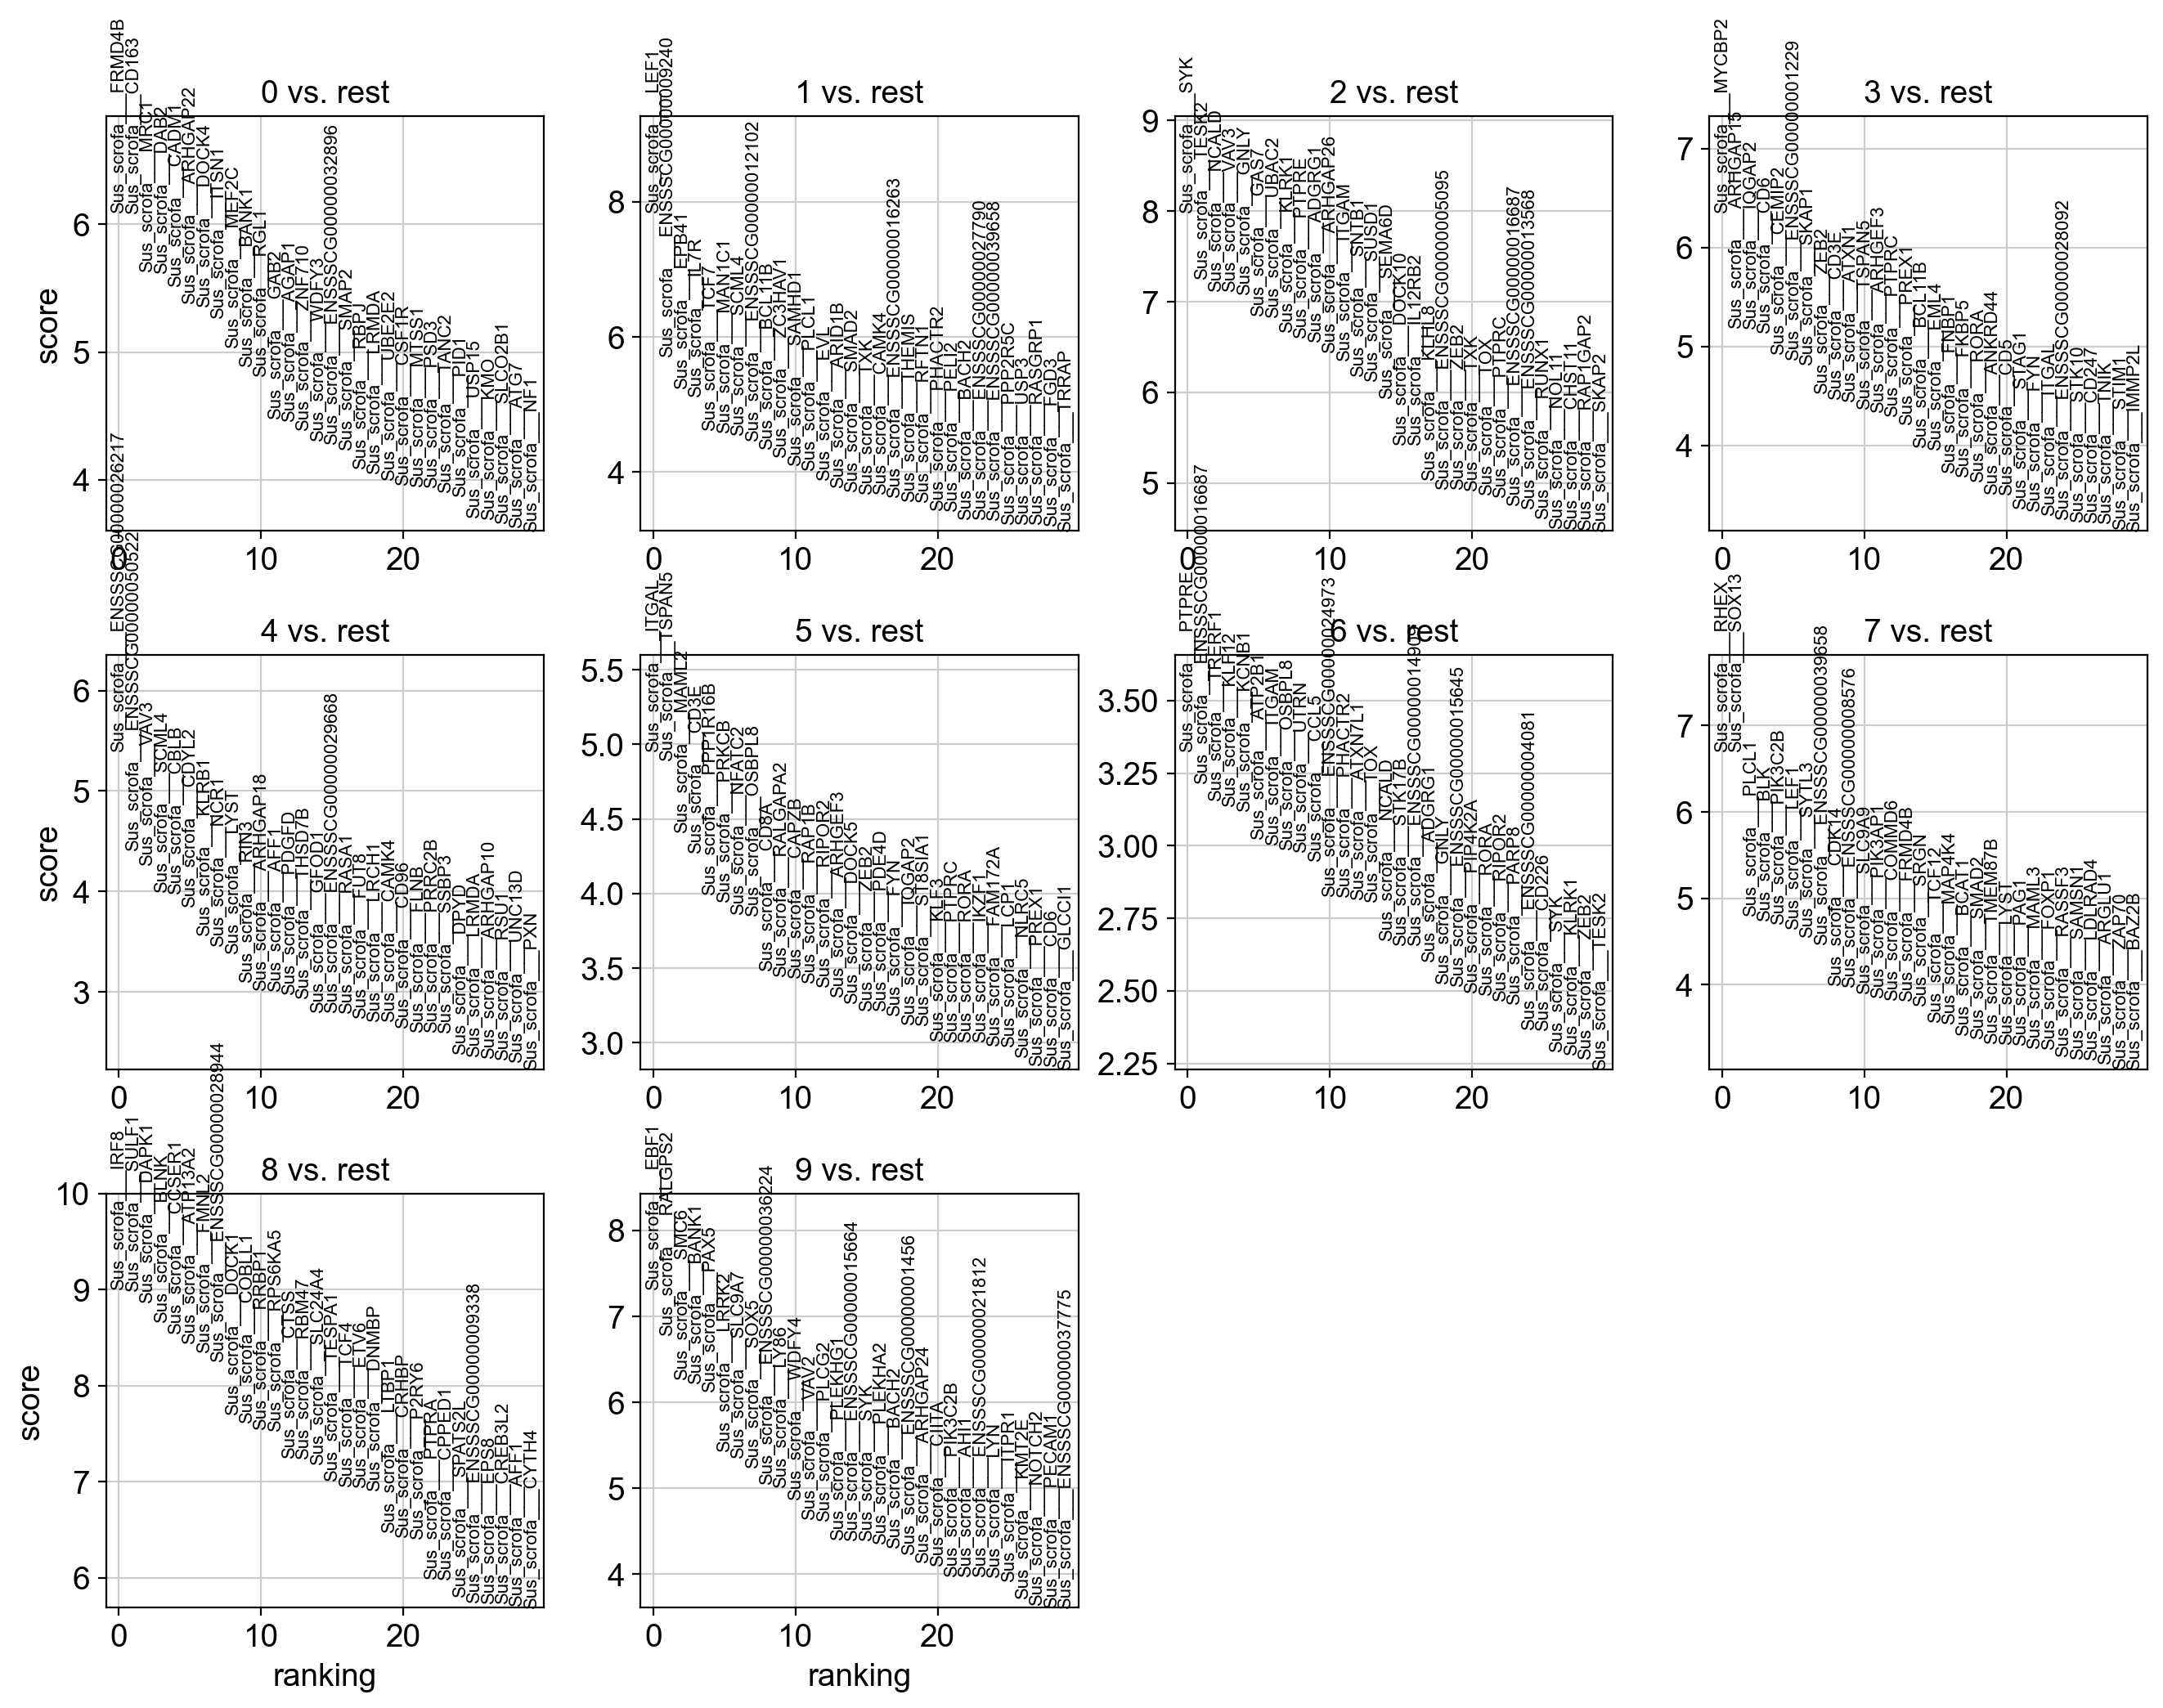

In [12]:
# Perform differential expression to find marker genes for each cluster using Wilcoxon test on raw data
sc.tl.rank_genes_groups(label_transferred_lognorm_pig_lymph, 'leiden_08', method='wilcoxon', key_added='wilcoxon')

# Visualize the top marker genes for each cluster
sc.pl.rank_genes_groups(label_transferred_lognorm_pig_lymph, key='wilcoxon', n_genes=30, sharey=False)

# Save the DE analysis to an H5AD file
dea_adata = label_transferred_lognorm_pig_lymph.write ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/dea_08_pig_lymphoids_v2.h5ad")

In [3]:
dea_adata = sc.read("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/dea_08_pig_lymphoids_v2.h5ad")

In [14]:
dea_adata

AnnData object with n_obs × n_vars = 559 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08', 'cell_states', 'pig_immune_leiden_10', 'new_endpoints', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'Average_expression', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable'
    uns: 'leiden_08_colors', 'log1p', 'wilcoxon'
    obsm: 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'dista

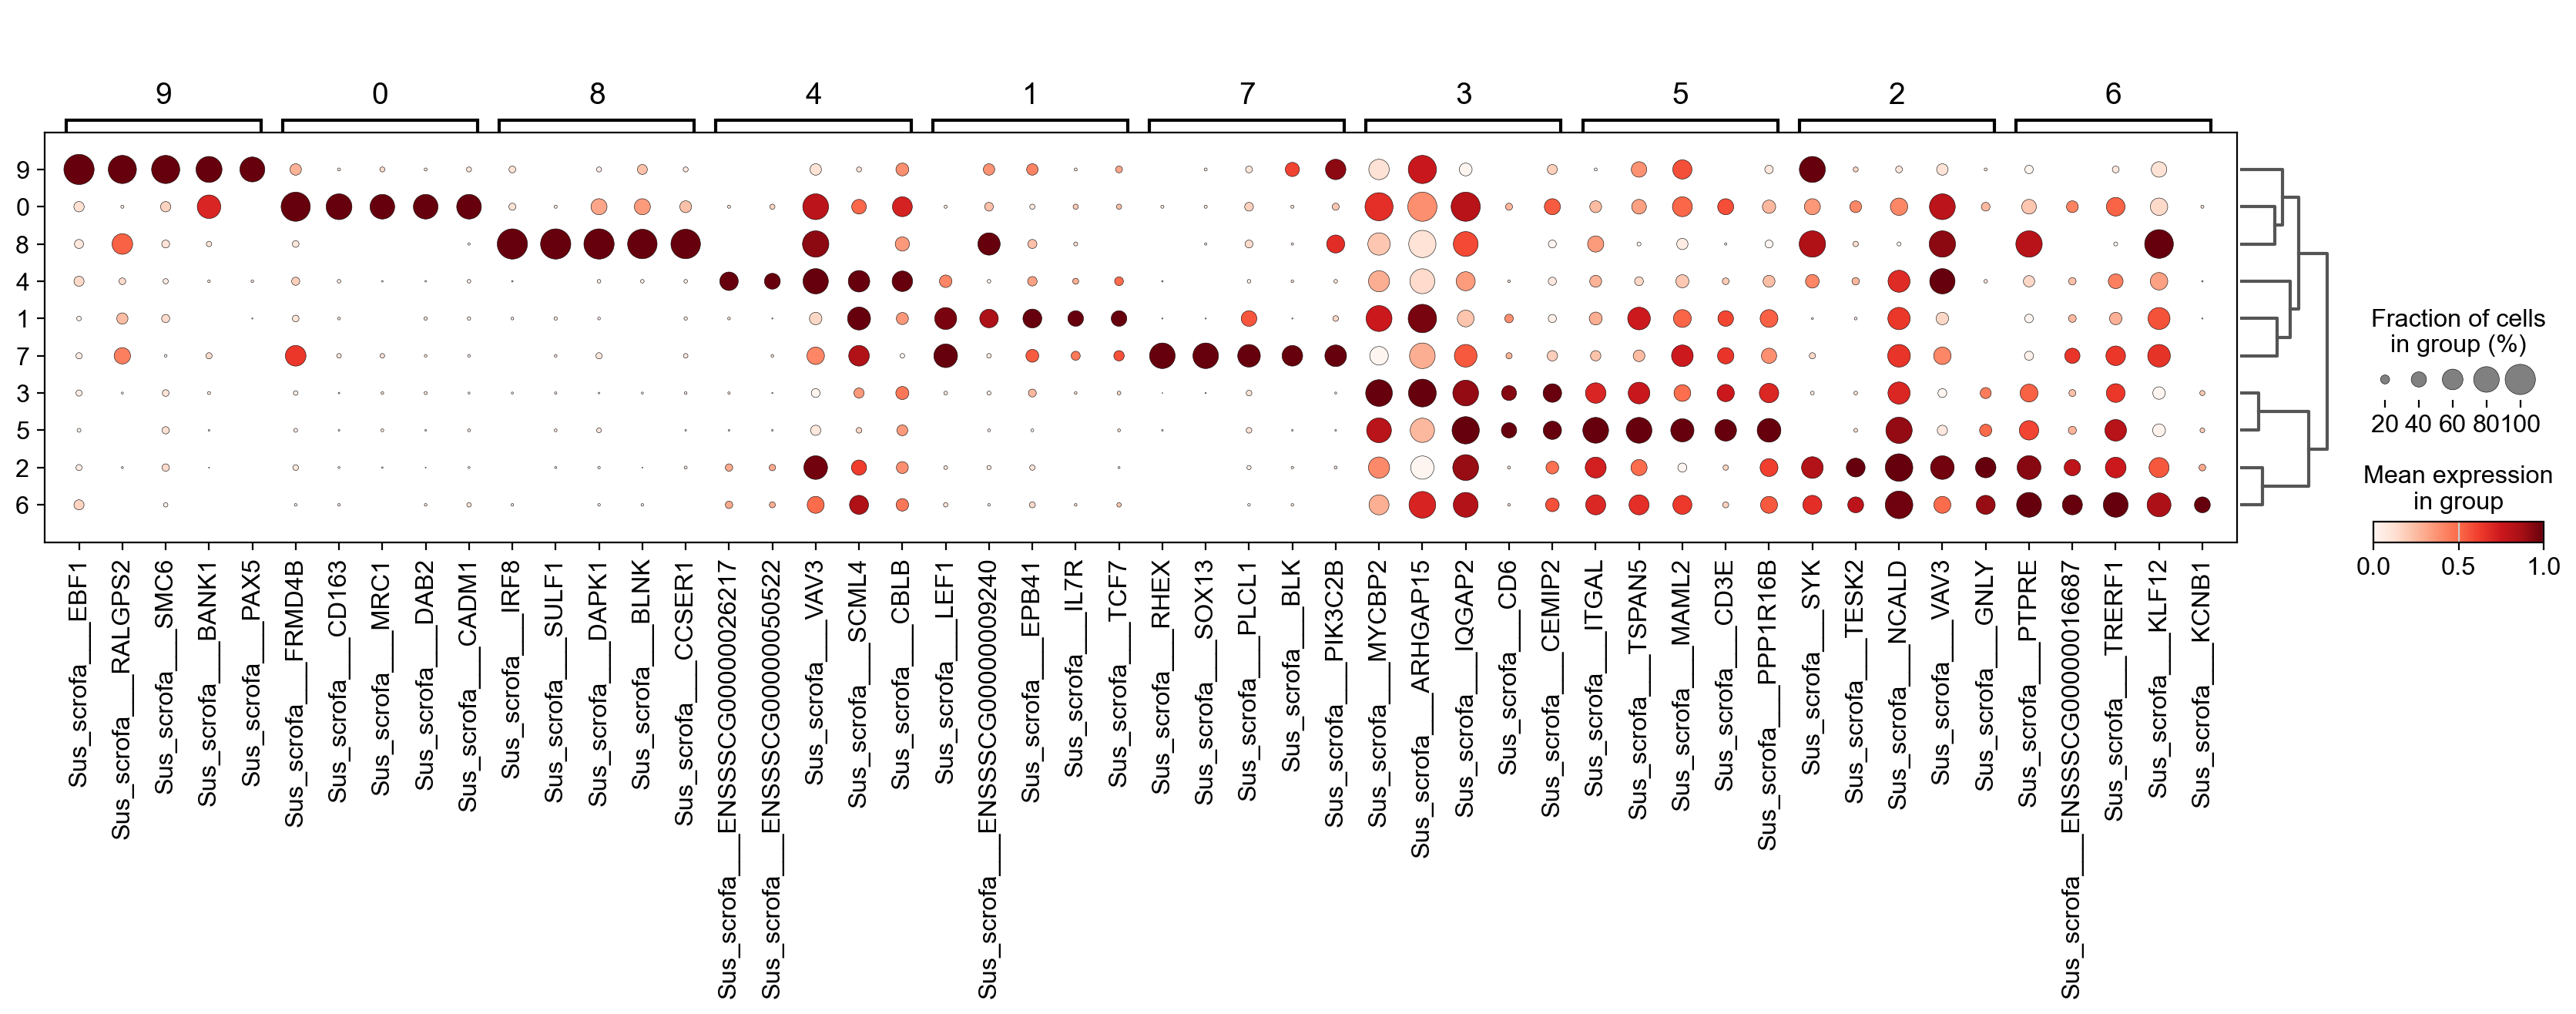

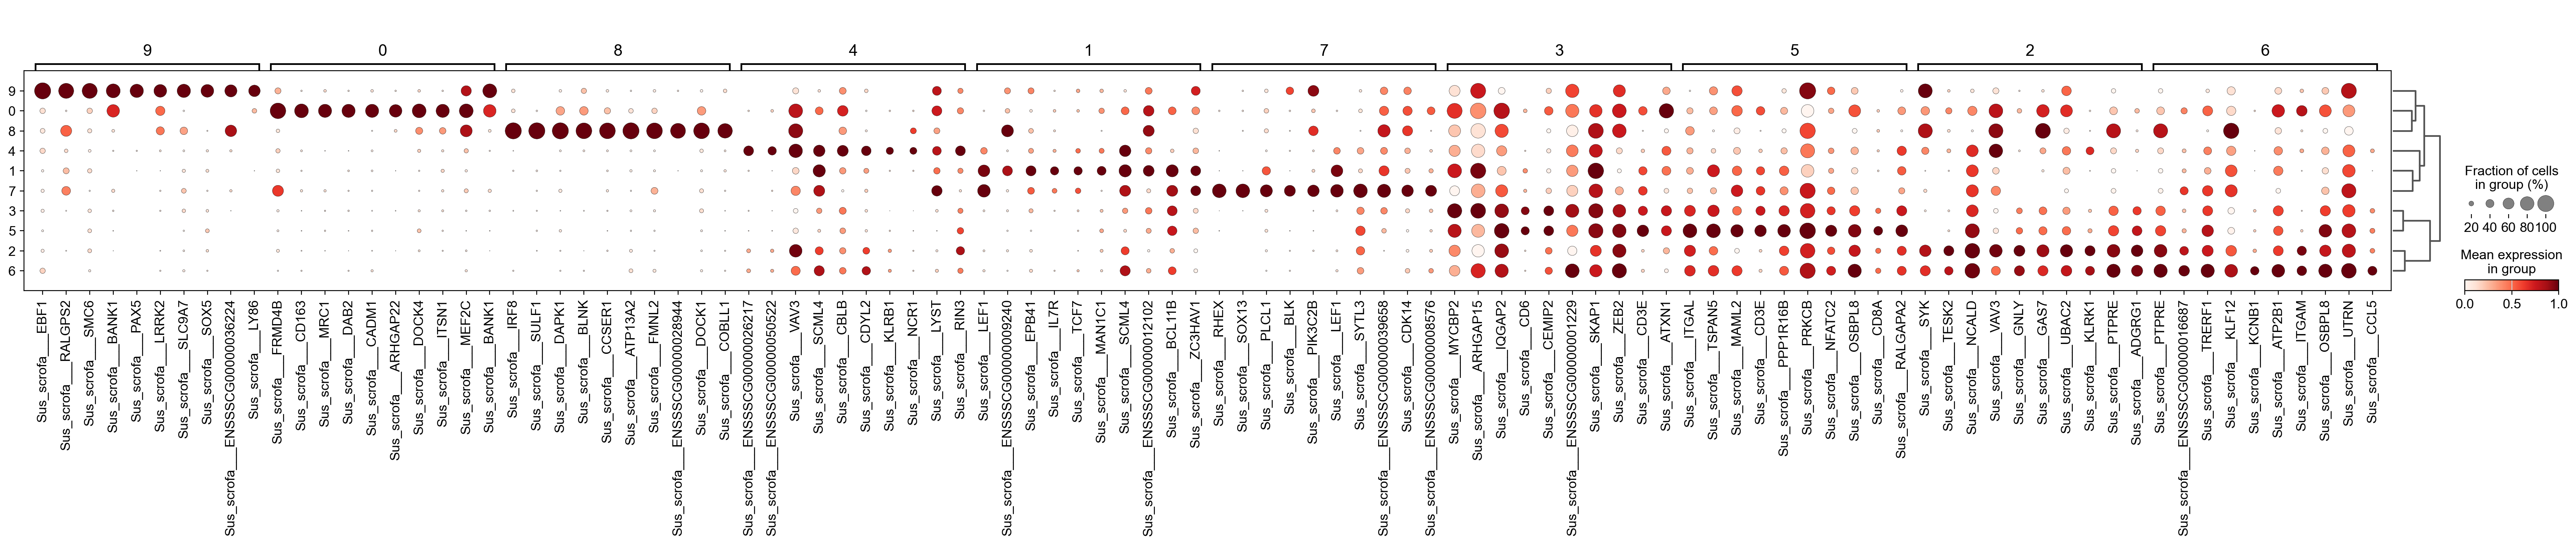

In [15]:
sc.pl.rank_genes_groups_dotplot(dea_adata, key="wilcoxon", n_genes=5, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )
sc.pl.rank_genes_groups_dotplot(dea_adata, key="wilcoxon", n_genes=10, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )

In [51]:
# Saving wilcoxon results directly
output_dir = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA 08/'
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

# Access the DE results stored in dea_adata.uns['wilcoxon']
de_results = dea_adata.uns['wilcoxon']

# Extract log-fold changes, p-values, and adjusted p-values
logfoldchanges = de_results['logfoldchanges']
pvals = de_results['pvals']
pvals_adj = de_results['pvals_adj']

# Loop through each cluster and save DEGs to a separate CSV file
for cluster in dea_adata.obs['leiden_08'].cat.categories:
    # Extract the top genes for the current cluster
    gene_names = de_results['names'][cluster]
    logfc = logfoldchanges[cluster]
    pval = pvals[cluster]
    adj_pval = pvals_adj[cluster]
    
    # Create a DataFrame for the cluster's DEGs
    degs_df = pd.DataFrame({
        'Gene': gene_names,
        'LogFoldChange': logfc,
        'PValue': pval,
        'AdjustedPValue': adj_pval
    })
    
    # Save the DataFrame to a CSV file
    output_file = os.path.join(output_dir, f"DEGs_cluster_{cluster}.csv")
    degs_df.to_csv(output_file, index=False)
    print(f"Saved DEGs for cluster {cluster} to {output_file}")

Saved DEGs for cluster 0 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA 08/DEGs_cluster_0.csv
Saved DEGs for cluster 1 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA 08/DEGs_cluster_1.csv
Saved DEGs for cluster 2 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA 08/DEGs_cluster_2.csv
Saved DEGs for cluster 3 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA 08/DEGs_cluster_3.csv
Saved DEGs for cluster 4 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA 08/DEGs_cluster_4.csv
Saved DEGs for cluster 5 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA 08/DEGs_cluster_5.csv
Saved DEGs for cluster 6 to /data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns obje

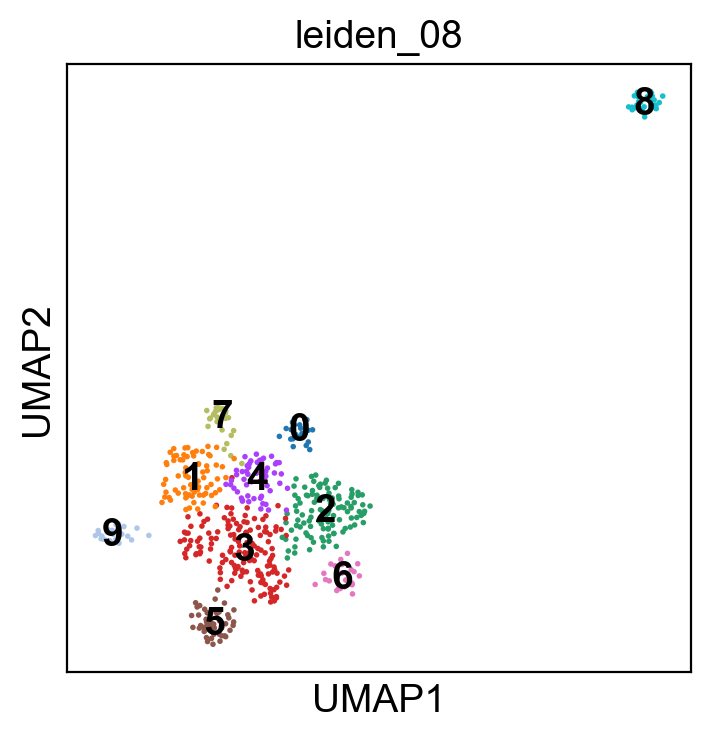

In [16]:
# Plot UMAP
sc.pl.umap(
    dea_adata, color=["leiden_08"], legend_loc="on data", size=16
)

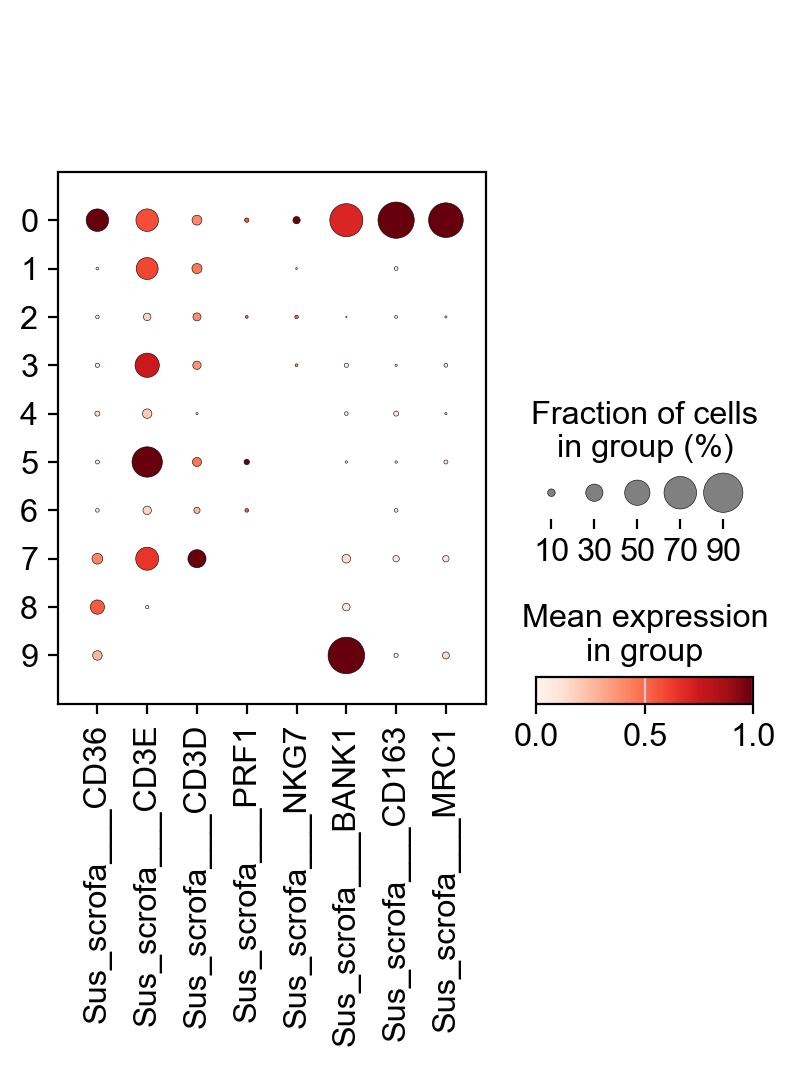

In [ ]:

B_cell_genes = [
    "Sus_scrofa___CD36","Sus_scrofa___CD3E", "Sus_scrofa___CD3D", "Sus_scrofa___PRF1", "Sus_scrofa___NKG7",
"Sus_scrofa___BANK1", 
    "Sus_scrofa___CD163",  "Sus_scrofa___MRC1"
]            

# Create the dot plot
sc.pl.dotplot(dea_adata, B_cell_genes, groupby='leiden_08', vmin=0, standard_scale = 'var')
# sc.pl.umap(dea_adata, color=B_cell_genes, cmap=dimplot_color, size=16)

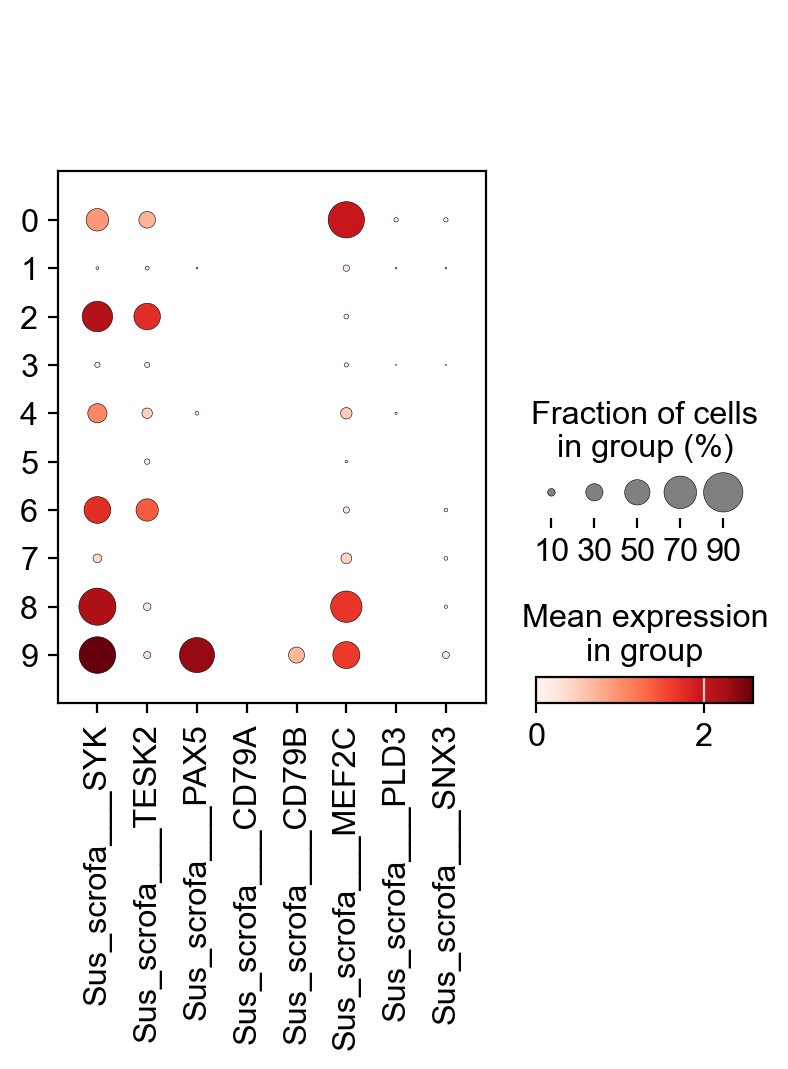

In [5]:
# 9 = B cells
B_cell_genes = [
    "Sus_scrofa___SYK","Sus_scrofa___TESK2", "Sus_scrofa___PAX5", "Sus_scrofa___CD79A", "Sus_scrofa___CD79B",
"Sus_scrofa___MEF2C","Sus_scrofa___PLD3", "Sus_scrofa___SNX3"]            

# Create the dot plot
sc.pl.dotplot(dea_adata, B_cell_genes, groupby='leiden_08', vmin=0)
# sc.pl.umap(dea_adata, color=B_cell_genes, cmap=dimplot_color, size=16)

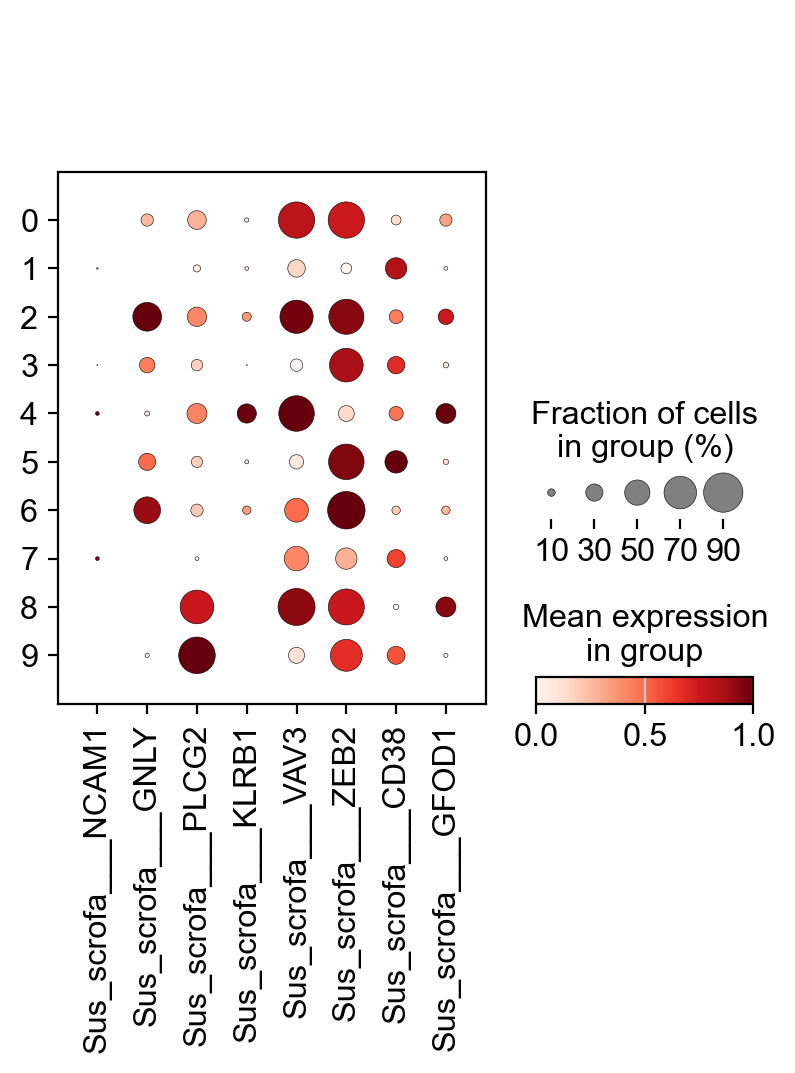

In [ ]:

genes = ["Sus_scrofa___NCAM1", "Sus_scrofa___GNLY", "Sus_scrofa___PLCG2", "Sus_scrofa___KLRB1", "Sus_scrofa___VAV3", "Sus_scrofa___ZEB2",  "Sus_scrofa___CD38", "Sus_scrofa___GFOD1"]            

# Create the dot plot
sc.pl.dotplot(dea_adata, genes, groupby='leiden_08', vmin=0, standard_scale = 'var')
# sc.pl.umap(dea_adata, color=genes, cmap=dimplot_color, size=16)

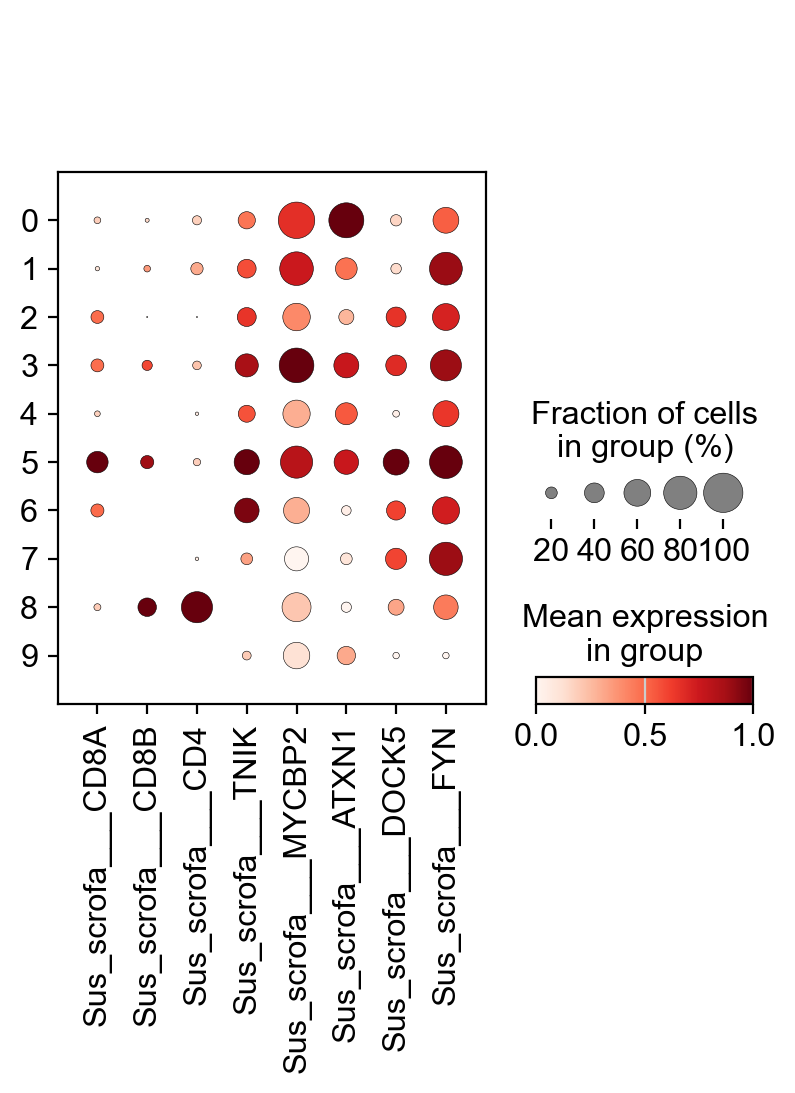

In [ ]:

genes = ["Sus_scrofa___CD8A", "Sus_scrofa___CD8B", "Sus_scrofa___CD4", 
         "Sus_scrofa___TNIK", "Sus_scrofa___MYCBP2", "Sus_scrofa___ATXN1", "Sus_scrofa___DOCK5", "Sus_scrofa___FYN"]
# Create the dot plot
sc.pl.dotplot(dea_adata, genes, groupby='leiden_08', vmin=0, 
              standard_scale = 'var'
             )
# sc.pl.umap(dea_adata, color=genes, cmap=dimplot_color, size=16)

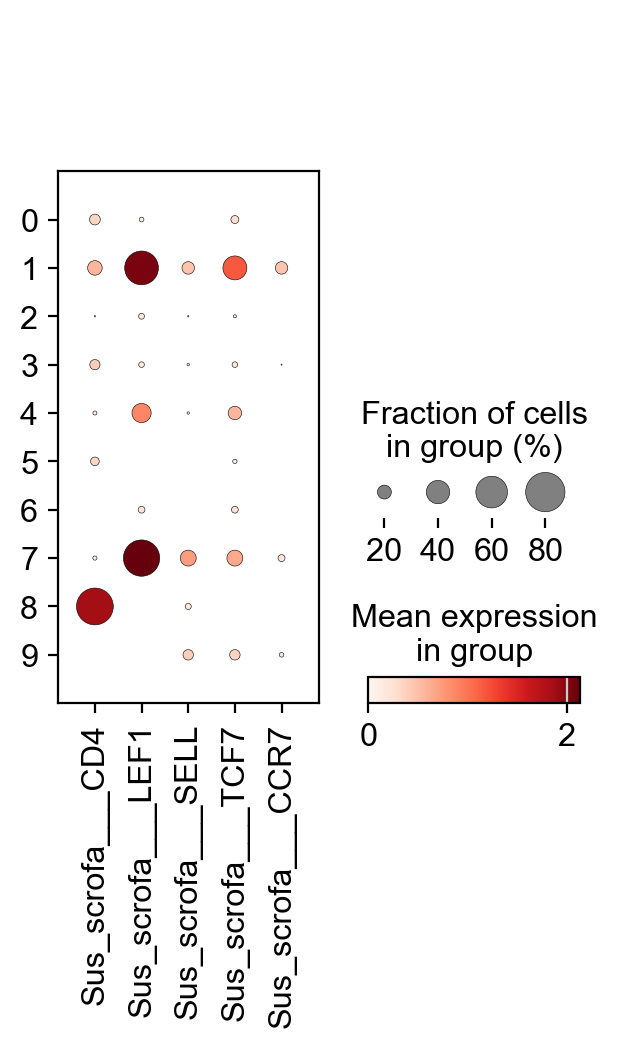

In [ ]:


genes = ["Sus_scrofa___CD4", "Sus_scrofa___LEF1", "Sus_scrofa___SELL", "Sus_scrofa___TCF7", "Sus_scrofa___CCR7"]
# Create the dot plot
sc.pl.dotplot(dea_adata, genes, groupby='leiden_08', vmin=0)
# sc.pl.umap(dea_adata, color=genes, cmap=dimplot_color, size=16)

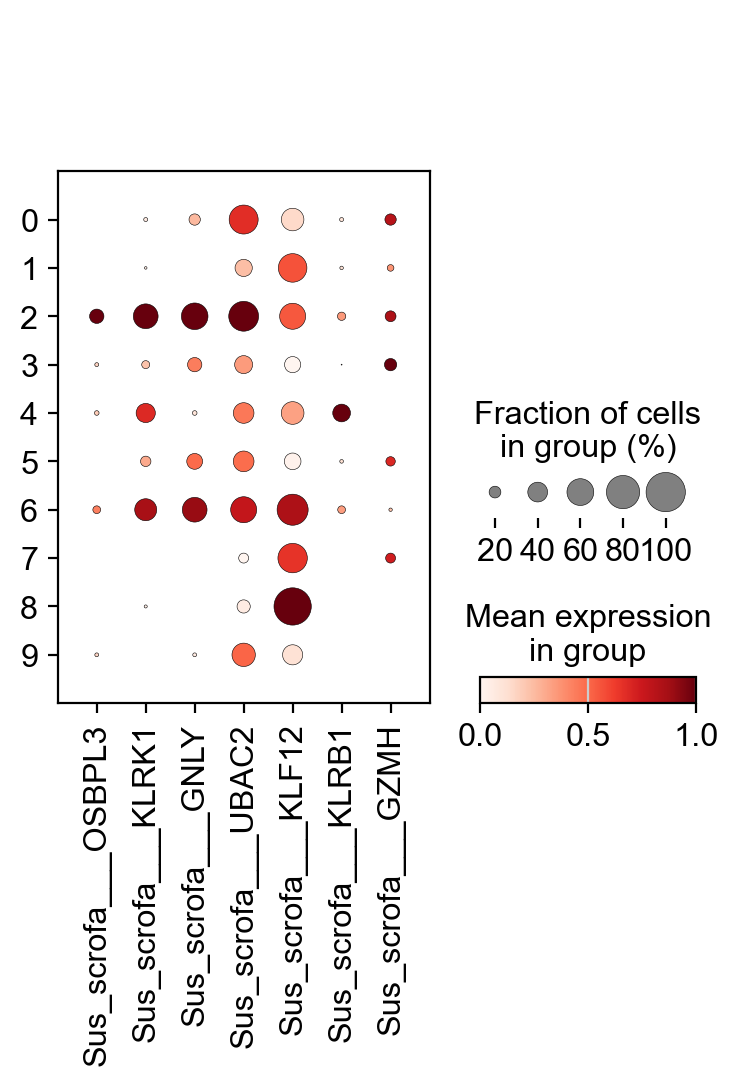

In [72]:
# 2: Cytotoxic T cell 

genes = [
    "Sus_scrofa___OSBPL3", "Sus_scrofa___KLRK1", "Sus_scrofa___GNLY", "Sus_scrofa___UBAC2", "Sus_scrofa___KLF12","Sus_scrofa___KLRB1","Sus_scrofa___GZMH"]
# Create the dot plot
sc.pl.dotplot(dea_adata, genes, groupby='leiden_08', vmin=0, standard_scale = 'var')
# sc.pl.umap(dea_adata, color=genes, cmap=dimplot_color, size=16)

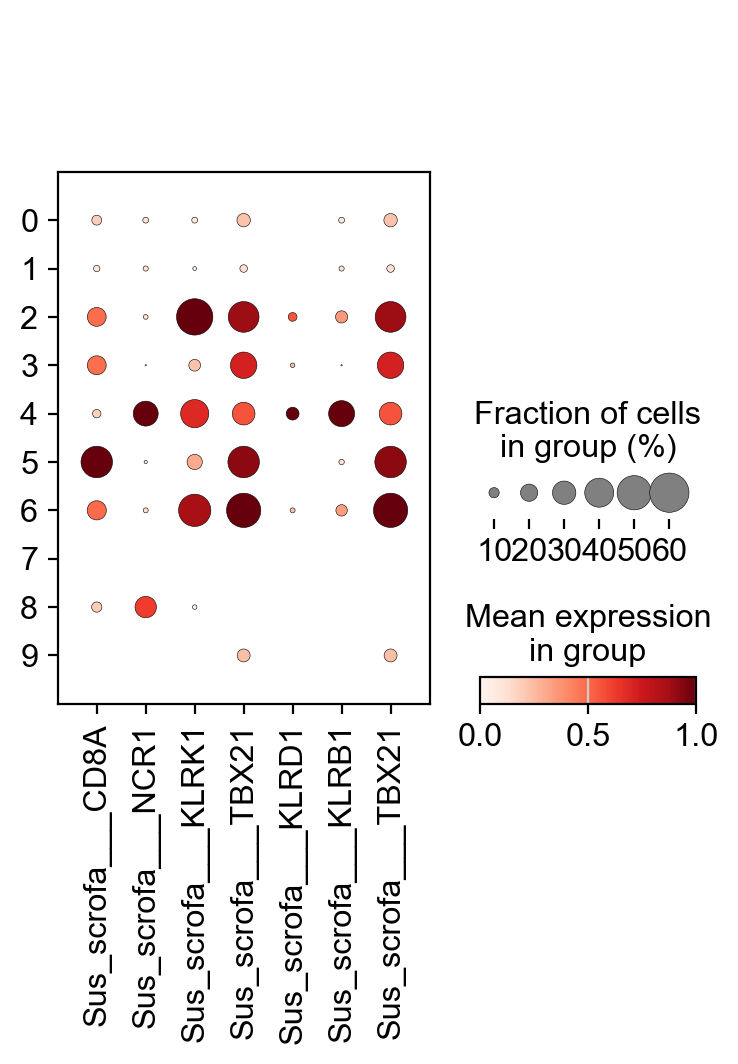

In [ ]:

genes = ["Sus_scrofa___CD8A", "Sus_scrofa___NCR1", 
         "Sus_scrofa___KLRK1", 
         "Sus_scrofa___TBX21", "Sus_scrofa___KLRD1", "Sus_scrofa___KLRB1", 
         "Sus_scrofa___TBX21"
        ]
# Create the dot plot
sc.pl.dotplot(dea_adata, genes, groupby='leiden_08', vmin=0, 
              standard_scale = 'var'
             )
# sc.pl.umap(dea_adata, color=genes, cmap=dimplot_color, size=16)

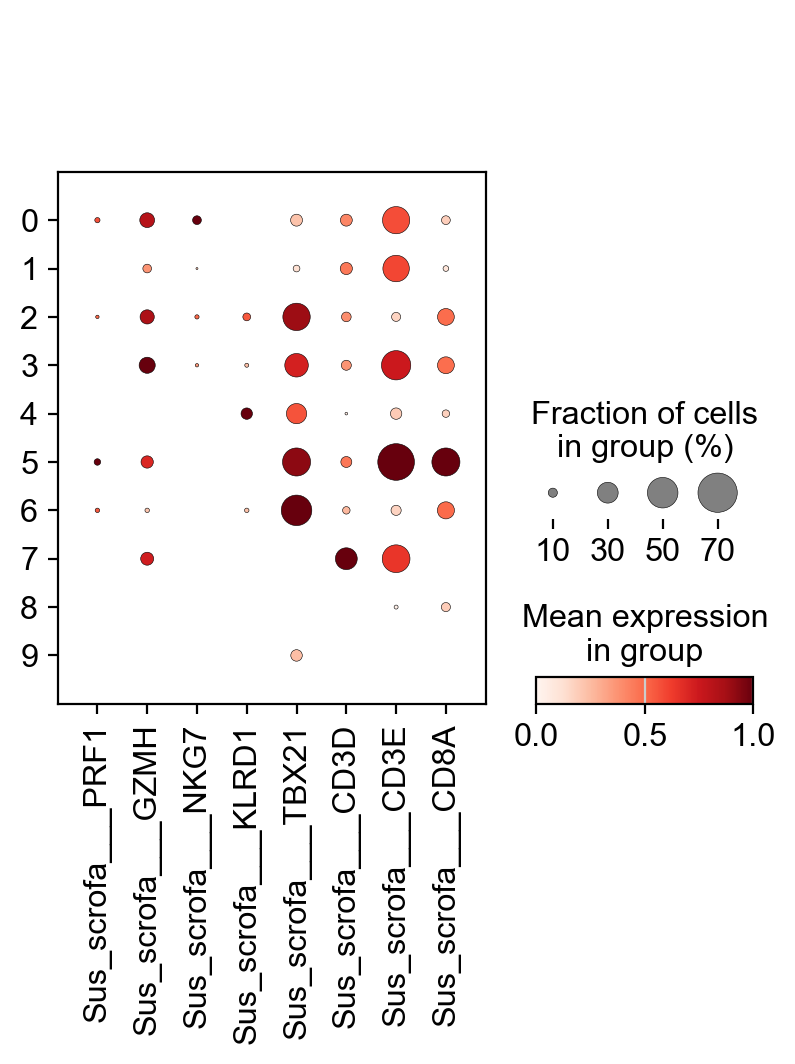

In [ ]:


genes = ["Sus_scrofa___PRF1", 
         "Sus_scrofa___GZMH",  "Sus_scrofa___NKG7",  "Sus_scrofa___KLRD1" ,  "Sus_scrofa___TBX21" , 
         "Sus_scrofa___CD3D", "Sus_scrofa___CD3E", "Sus_scrofa___CD8A", # If 2 and 6 are NK cells, they shouldnt have CD3 markers, or else they would be cytotoxic T cells
         # "Sus_scrofa___CTLA4", "Sus_scrofa___IL2RA", "Sus_scrofa___IKZF2"
        ]
# Create the dot plot
sc.pl.dotplot(dea_adata, genes, groupby='leiden_08', vmin=0, standard_scale = 'var')
# sc.pl.umap(dea_adata, color=genes, cmap=dimplot_color, size=16)

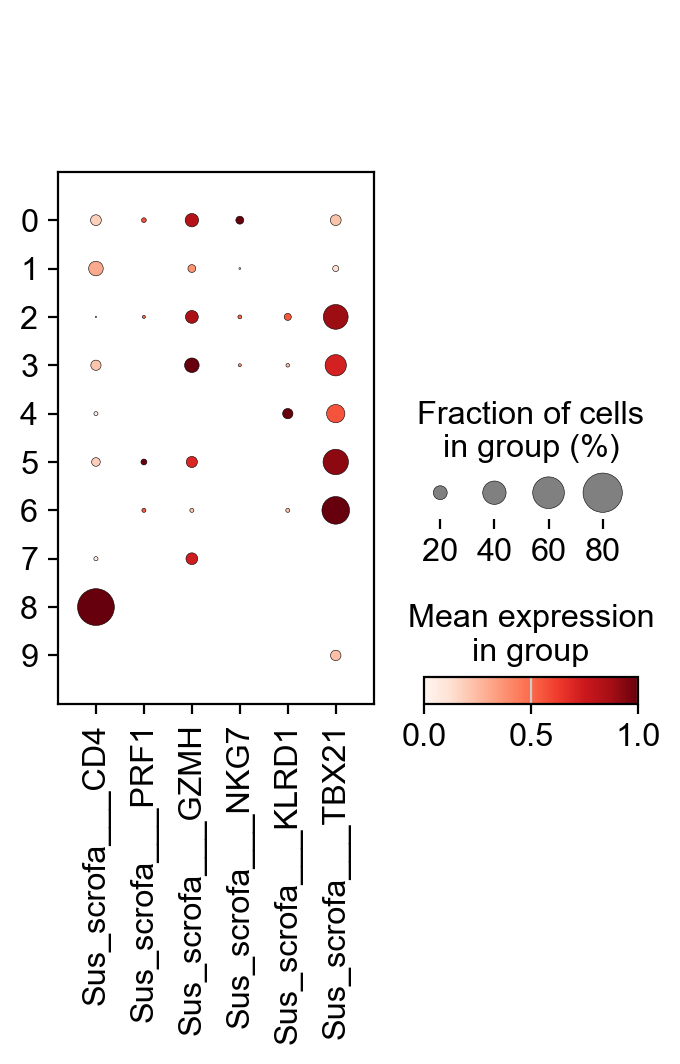

In [ ]:

genes = ["Sus_scrofa___CD4", "Sus_scrofa___PRF1", 
         "Sus_scrofa___GZMH",  "Sus_scrofa___NKG7",  "Sus_scrofa___KLRD1" ,  "Sus_scrofa___TBX21" , 
         # "Sus_scrofa___FCGR3A", # If 2 and 6 are NK cells, they shouldnt have CD3 markers, or else they would be cytotoxic T cells
         # "Sus_scrofa___CTLA4", "Sus_scrofa___IL2RA", "Sus_scrofa___IKZF2"
        ]
# Create the dot plot
sc.pl.dotplot(dea_adata, genes, groupby='leiden_08', vmin=0, standard_scale = 'var')
# sc.pl.umap(dea_adata, color=genes, cmap=dimplot_color, size=16)

In [4]:
cluster_annotations = {
    "0": "Sus_unassigned",
    "1": "Sus_CD4T_naive",
    "2": "Sus_NK_CD16hi_IFNhi",
    "3": "CD8T_cytox_1",
    "4": "Sus_NK_CD69hi",
    "5": "CD8T_cytox_2",
    "6": "Sus_NK_CD16hi",
    "7": "Sus_innate_lymphoid_cells",
    "8": "Sus_unclassified",
    "9": "Sus_B_cells"
}

In [5]:

# Add annotations to the adata object
dea_adata.obs["leiden_08_named"] = dea_adata.obs['leiden_08'].astype(str).map(cluster_annotations)


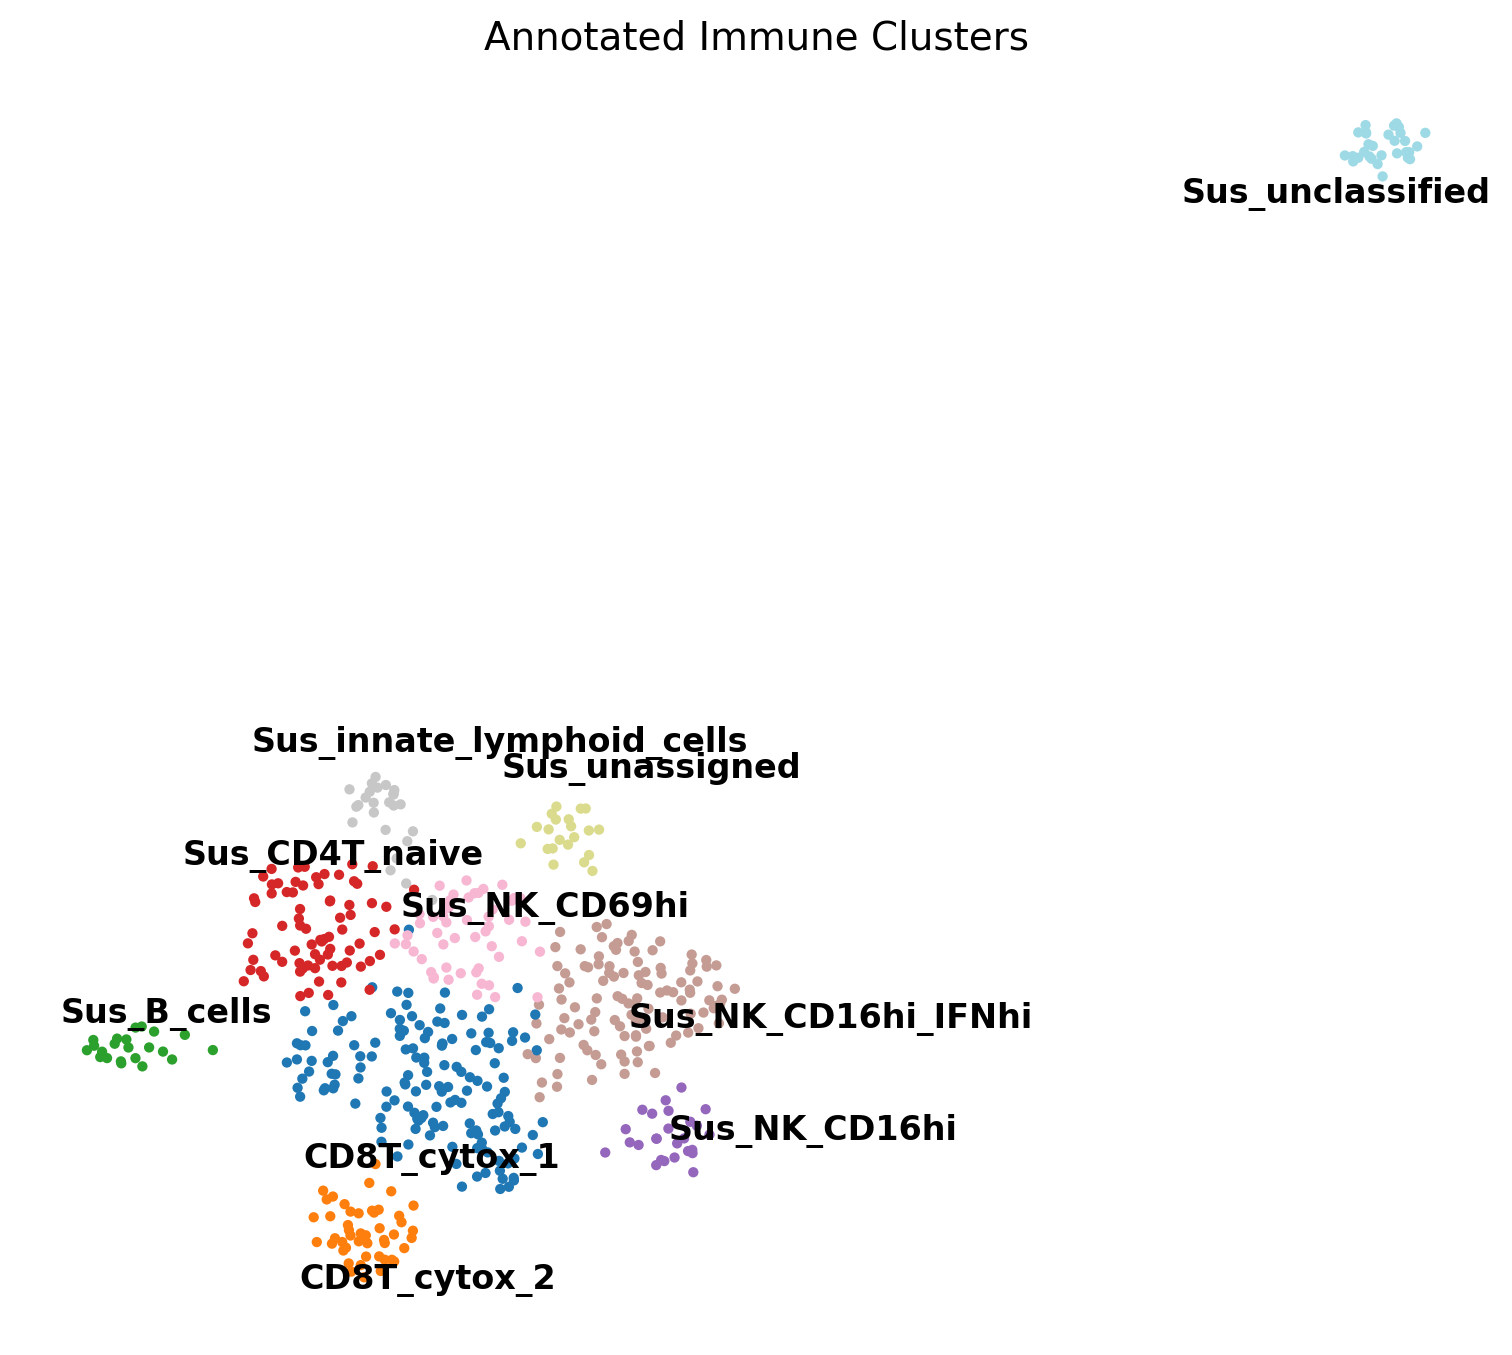

In [6]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# Set smaller figure size (reduced from 14,12 to 10,8)
plt.figure(figsize=(8, 7))

# Plot UMAP with even bigger dots (increased from 40 to 50)
sc.pl.umap(
    dea_adata,
    color="leiden_08_named",
    palette="tab20",
    legend_loc=None,  # No legend
    title="Annotated Immune Clusters",
    frameon=False,
    size=55,  # Increased dot size
    show=False,
    ax=plt.gca()
)

# Calculate cluster positions with offset
umap_coords = dea_adata.obsm['X_umap']
clusters = dea_adata.obs['leiden_08_named'].unique()

# Predefined label offsets (same as before)
label_offsets = {
    "Sus_unassigned": (-1, 1),
    "Sus_CD4T_naive": (-2, 1.3),
    "Sus_NK_CD16hi_IFNhi": (0, -0.5),
    "CD8T_cytox_1": (-2, -1.6),
    "Sus_NK_CD69hi": (-1, 0.3),
    "CD8T_cytox_2": (-1, -1),
    "Sus_NK_CD16hi": (0, 0),
    "Sus_innate_lymphoid_cells": (-2, 1),
    "Sus_unclassified": (-3, -1),
    "Sus_B_cells": (-1, 0.5)
}

# Add labels (unchanged)
for cluster in clusters:
    mask = dea_adata.obs['leiden_08_named'] == cluster
    x, y = np.median(umap_coords[mask], axis=0)
    dx, dy = label_offsets.get(cluster, (0, 0))
    
    plt.text(
        x + dx, y + dy, cluster,
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

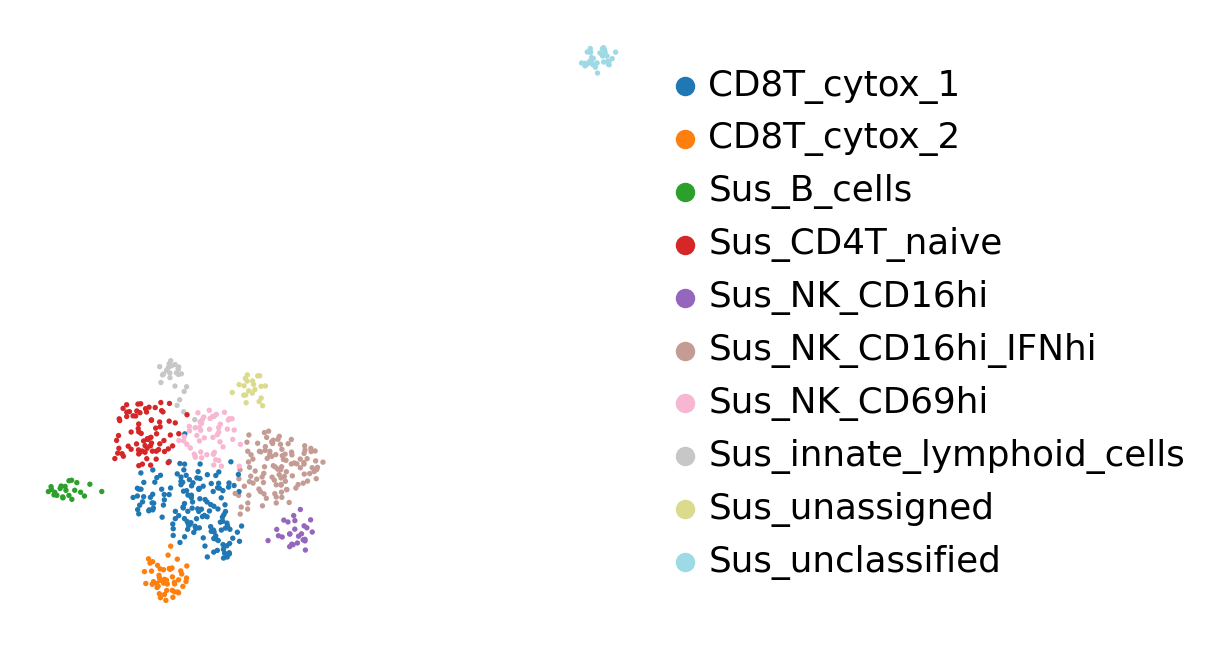

In [7]:


# Now plot again just to add the legend on the right using a blank figure
sc.pl.umap(
    dea_adata,
    color="leiden_08_named",
    palette="tab20",
    legend_loc='right margin',  # <- THIS enables the legend on the right
    frameon=False,
    size=15,
    title="",
    show=True
)


In [10]:
annotated_lymphoid_pig = dea_adata.write ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/final objects/annotated_pig_lymphoids_final.h5ad")

In [11]:
annotated_lymphoid_pig = sc.read ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/final objects/annotated_pig_lymphoids_final.h5ad")

In [13]:
annotated_dea_adata = sc.read ("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Finns objects/Pig immune-lymphoids reclustering/DEA_annotated_pig_lymphoids_08_v1.h5ad")

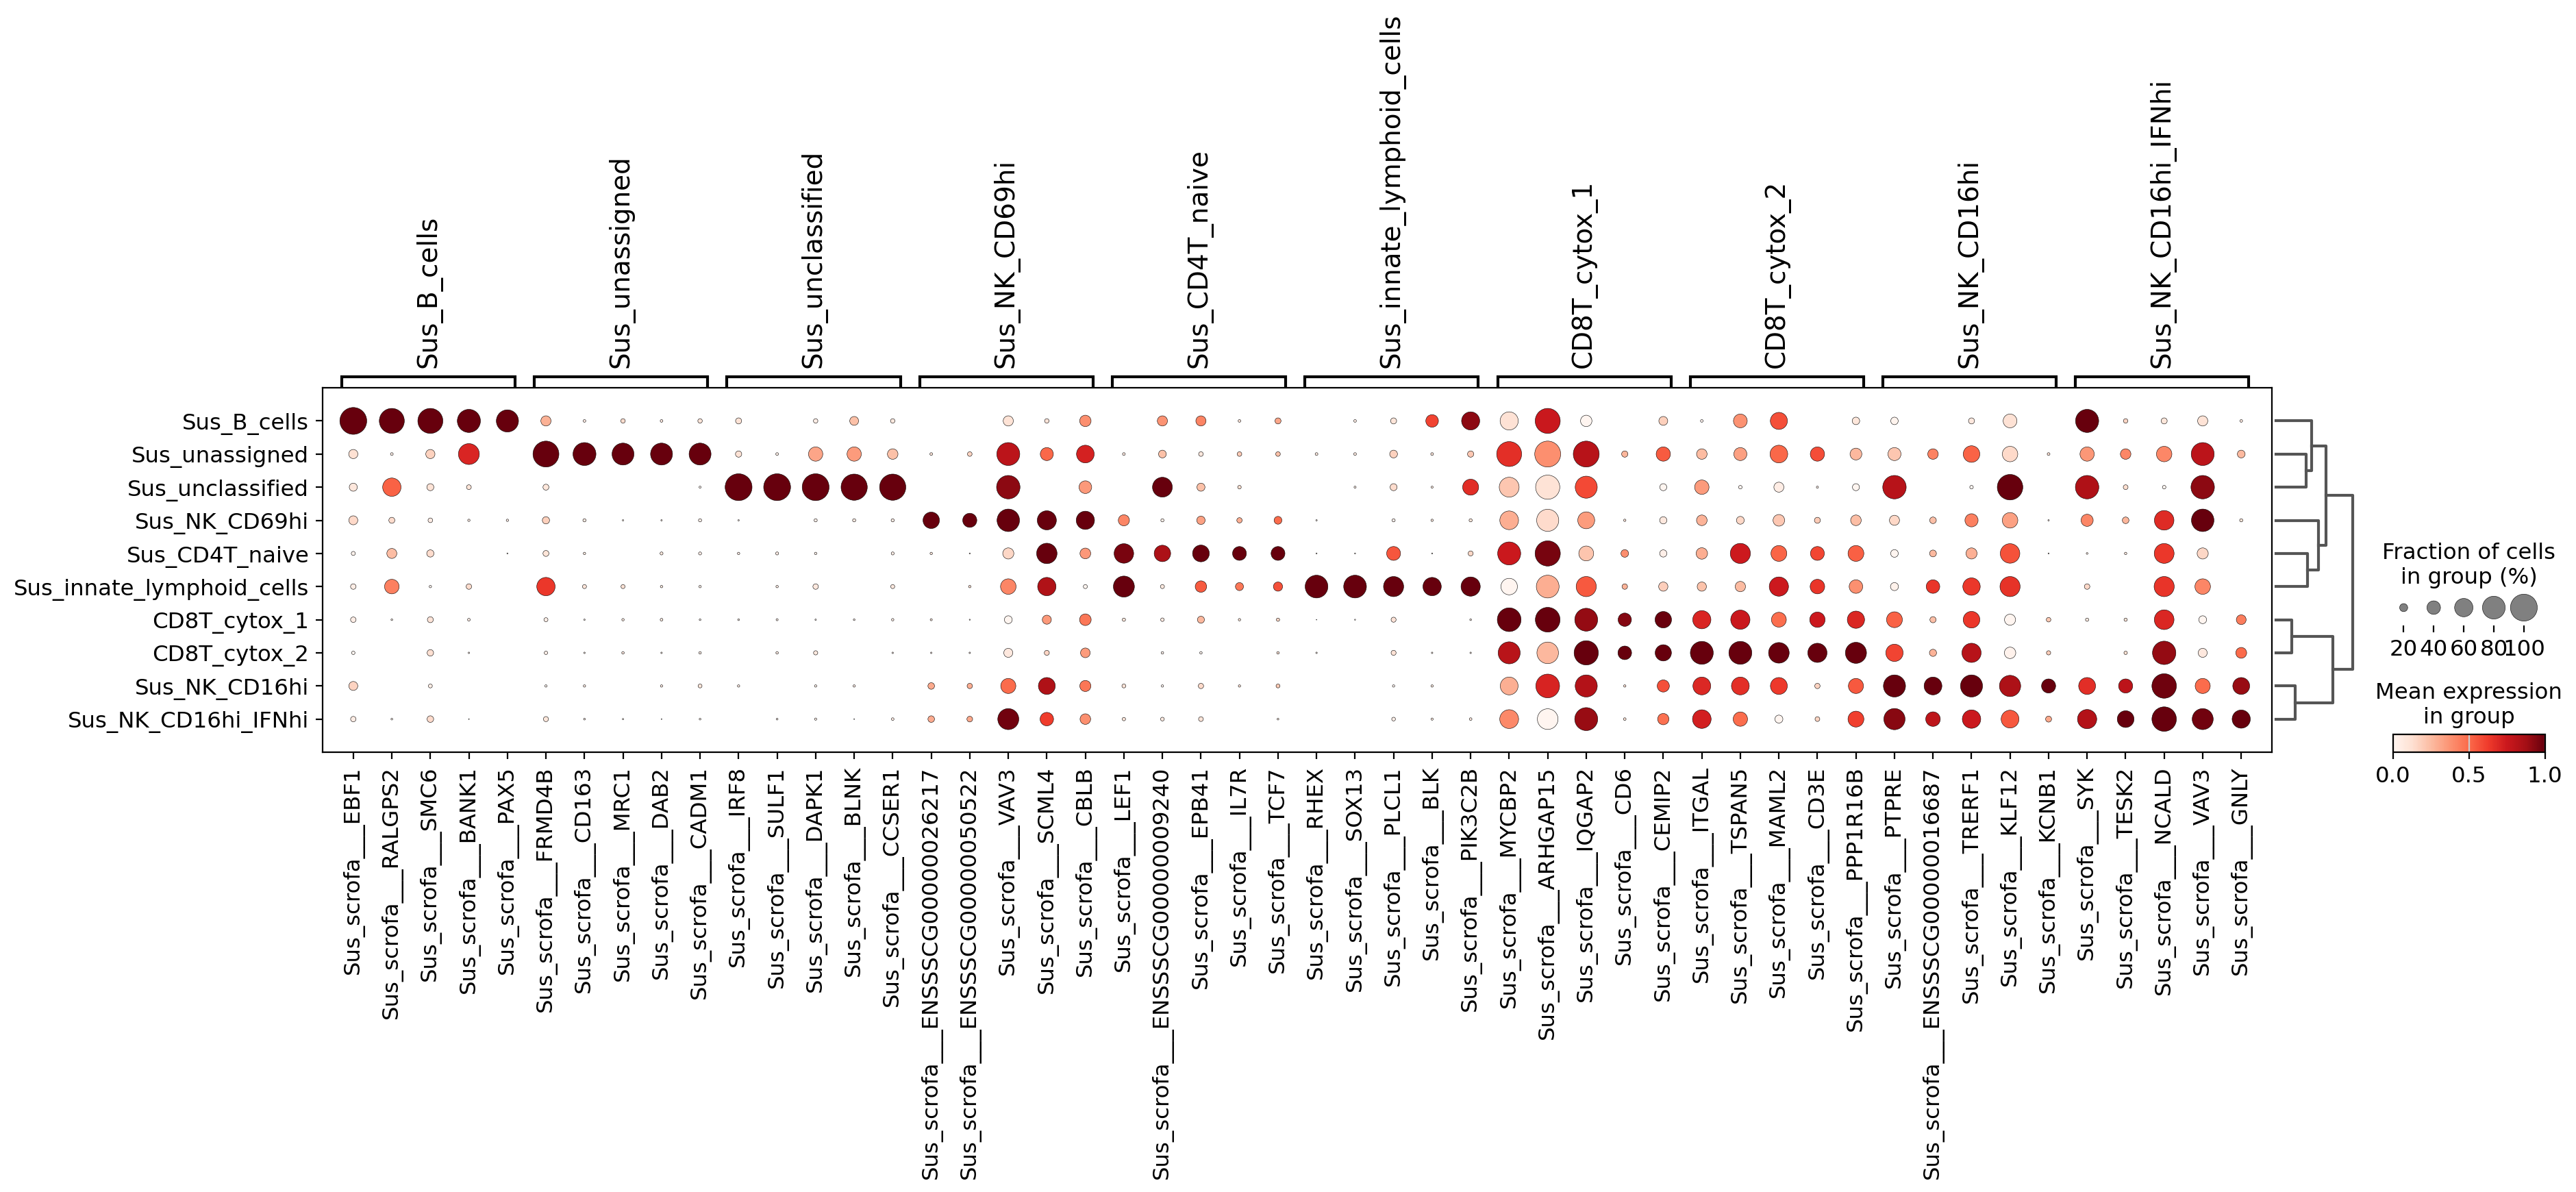

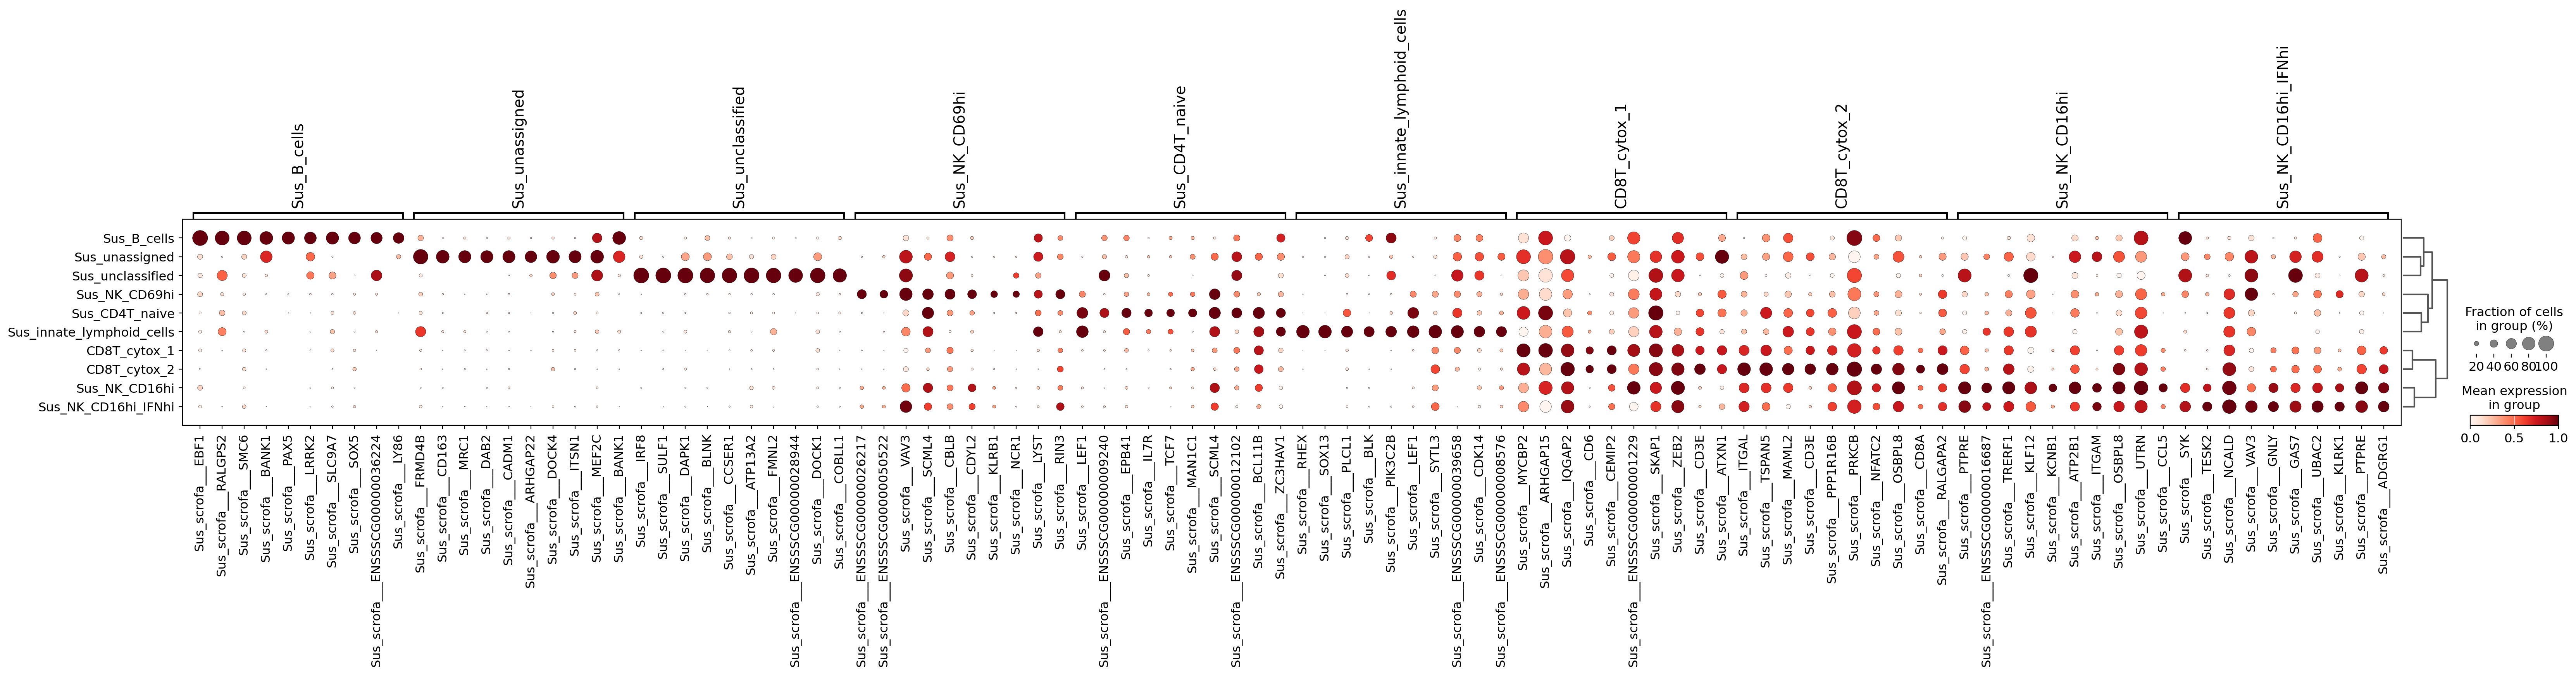

In [14]:
sc.pl.rank_genes_groups_dotplot(annotated_dea_adata, key="wilcoxon_ann", n_genes=5, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )
sc.pl.rank_genes_groups_dotplot(annotated_dea_adata, key="wilcoxon_ann", n_genes=10, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )